# 🎓 Predicción de Deserción Estudiantil

**Objetivo:** Construir un modelo supervisado que identifique estudiantes en riesgo de abandono a partir de patrones de comportamiento en la plataforma e-learning.

**Datos fuente:** Base de datos Moodle, MariaDB 11.4.10, exportada el 02-05-2026

---
| Sección | Tema | Ponderación |
|---------|------|-------------|
| 2 | Análisis Exploratorio (EDA) | 30% |
| 3 | Limpieza y Preparación de Datos | 40% |
| 4 | Feature Engineering | 30% |


## 1. Configuración e Importación de Datos


In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paleta institucional
COLORS = ['#2E86AB', '#E84855', '#F6AE2D', '#3BB273', '#7B4F9E']
sns.set_theme(style='whitegrid', palette=COLORS)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

print(' Librerías cargadas correctamente')


 Librerías cargadas correctamente


In [2]:
SQL_PATH = 'accibztw_edu_accion.sql'  # ← ajustar ruta si es necesario

with open(SQL_PATH, 'r', encoding='utf-8', errors='replace') as f:
    SQL_CONTENT = f.read()

def _parse_row(text: str) -> list:
    """Parsea una fila SQL (contenido entre paréntesis) a lista de valores Python."""
    values, i = [], 0
    ESCAPES = {'n': '\n', 't': '\t', 'r': '\r', "'": "'", '"': '"', '\\': '\\'}
    while i < len(text):
        c = text[i]
        if text[i:i+4] == 'NULL':
            values.append(None); i += 4
        elif c == "'":
            j, s = i + 1, []
            while j < len(text):
                if text[j] == '\\' and j + 1 < len(text):
                    s.append(ESCAPES.get(text[j+1], text[j+1])); j += 2
                elif text[j] == "'":
                    j += 1; break
                else:
                    s.append(text[j]); j += 1
            values.append(''.join(s)); i = j
        elif c in '0123456789-':
            j = i + 1
            while j < len(text) and text[j] in '0123456789.eE+-': j += 1
            raw = text[i:j]
            try: values.append(float(raw) if '.' in raw else int(raw))
            except: values.append(raw)
            i = j
        elif c in ', \n\r': i += 1
        else: i += 1
    return values

def load_table(table: str) -> pd.DataFrame:
    """Extrae una tabla completa del dump SQL y la devuelve como DataFrame."""
    m = re.search(rf'INSERT INTO `{table}` \(([^)]+)\) VALUES', SQL_CONTENT)
    if not m:
        return pd.DataFrame()
    cols = [c.strip().strip('`') for c in m.group(1).split(',')]
    all_rows = []
    for m in re.finditer(rf'INSERT INTO `{table}` \([^)]+\) VALUES\n', SQL_CONTENT):
        pos = m.end()
        depth, start, in_str, esc, str_char, i = 0, -1, False, False, None, pos
        while i < len(SQL_CONTENT):
            c = SQL_CONTENT[i]
            if esc: esc = False; i += 1; continue
            if c == '\\' and in_str: esc = True; i += 1; continue
            if in_str:
                if c == str_char: in_str = False
            elif c == "'":
                in_str = True; str_char = c
            elif c == '(':
                depth += 1
                if depth == 1: start = i + 1
            elif c == ')':
                depth -= 1
                if depth == 0 and start >= 0:
                    all_rows.append(_parse_row(SQL_CONTENT[start:i]))
                    start = -1
            elif c == ';' and depth == 0:
                break
            i += 1
    return pd.DataFrame(all_rows, columns=cols) if all_rows else pd.DataFrame(columns=cols)

print(' Parser SQL definido')


 Parser SQL definido


In [3]:
# Cargar tablas relevantes para análisis de deserción
print('Cargando tablas...')
df_users    = load_table('mdl_user')
df_enrol    = load_table('mdl_user_enrolments')
df_enrol_m  = load_table('mdl_enrol')
df_course   = load_table('mdl_course')
df_compl    = load_table('mdl_course_completions')
df_log      = load_table('mdl_logstore_standard_log')
df_grades   = load_table('mdl_grade_grades')
df_forum_posts = load_table('mdl_forum_posts')        # ← NUEVO: para feature de foros
df_forum_disc  = load_table('mdl_forum_discussions')  # ← NUEVO: para vincular foro-curso
df_mod_compl   = load_table('mdl_course_modules_completion')  # ← NUEVO: completud por módulo

print(f'  mdl_user                      : {len(df_users):>6} filas')
print(f'  mdl_user_enrolments           : {len(df_enrol):>6} filas')
print(f'  mdl_enrol                     : {len(df_enrol_m):>6} filas')
print(f'  mdl_course                    : {len(df_course):>6} filas')
print(f'  mdl_course_completions        : {len(df_compl):>6} filas')
print(f'  mdl_logstore                  : {len(df_log):>6} filas')
print(f'  mdl_grade_grades              : {len(df_grades):>6} filas')
print(f'  mdl_forum_posts               : {len(df_forum_posts):>6} filas')
print(f'  mdl_forum_discussions         : {len(df_forum_disc):>6} filas')
print(f'  mdl_course_modules_completion : {len(df_mod_compl):>6} filas')
print(f'\n Tablas cargadas. Log total de eventos: {len(df_log):,}')


Cargando tablas...
  mdl_user                      :    537 filas
  mdl_user_enrolments           :    119 filas
  mdl_enrol                     :      3 filas
  mdl_course                    :      2 filas
  mdl_course_completions        :    136 filas
  mdl_logstore                  : 132668 filas
  mdl_grade_grades              :      1 filas
  mdl_forum_posts               :     24 filas
  mdl_forum_discussions         :     21 filas
  mdl_course_modules_completion :   2878 filas

 Tablas cargadas. Log total de eventos: 132,668


### 2.1 Visión general del dataset

Se presenta la información general del curso analizado, incluyendo nombre, período y cantidad de matriculados. Permite verificar que los datos corresponden al contexto correcto antes de cualquier análisis.


In [4]:
COURSE_ID = 20
curso = df_course[df_course['id'] == COURSE_ID].iloc[0]
print('=' * 60)
print(f'CURSO   : {curso["fullname"]}')
print(f'ID      : {curso["id"]}')
print(f'Inicio  : {datetime.fromtimestamp(curso["startdate"]).strftime("%d/%m/%Y") if curso["startdate"] else "Sin fecha"}')
print('=' * 60)
print(f'\n  Estudiantes matriculados : {len(df_enrol)}')
print(f'  Registros de completud  : {len(df_compl)}')
print(f'  Eventos en log total    : {len(df_log):,}')
log20 = df_log[df_log['courseid'] == COURSE_ID].copy()
print(f' Eventos en curso 20     : {len(log20):,}')
print(f'  Usuarios únicos en log  : {df_log["userid"].nunique()}')


CURSO   : Masculinidades Positivas para la Prevención de la Violencia
ID      : 20
Inicio  : 18/08/2024

  Estudiantes matriculados : 119
  Registros de completud  : 136
  Eventos en log total    : 132,668
 Eventos en curso 20     : 5,156
  Usuarios únicos en log  : 364


### 2.2 Distribución temporal de la actividad


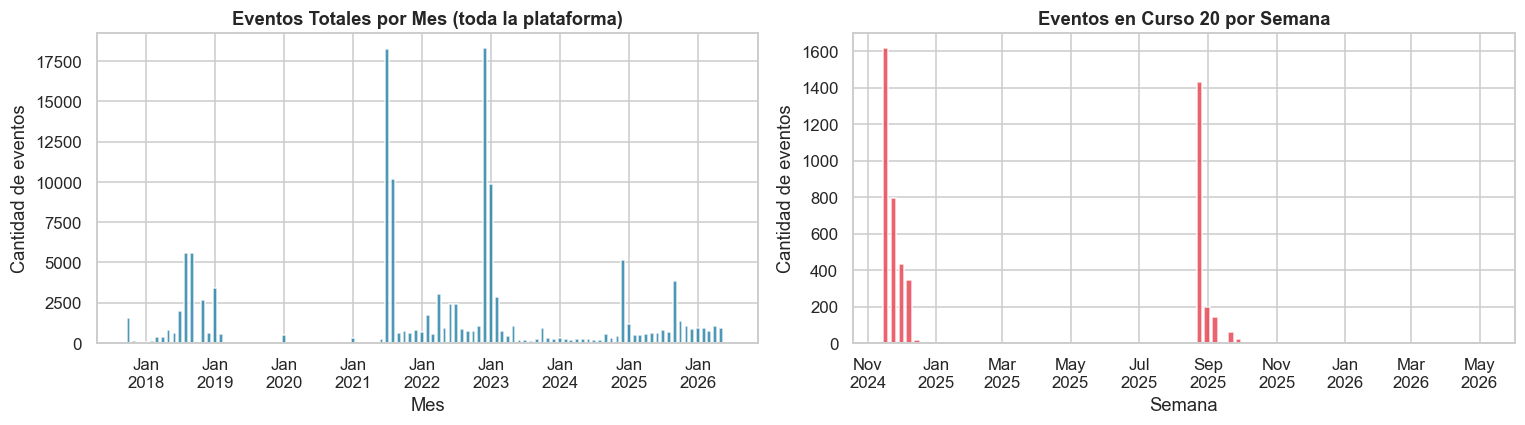

Período de actividad: 2024-11-12 → 2026-05-02


In [5]:
df_log['fecha'] = pd.to_datetime(df_log['timecreated'], unit='s')
log20['fecha'] = pd.to_datetime(log20['timecreated'], unit='s')
df_enrol['fecha_inicio'] = pd.to_datetime(df_enrol['timestart'], unit='s')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

eventos_mes = df_log.set_index('fecha').resample('ME').size()
axes[0].bar(eventos_mes.index, eventos_mes.values, color=COLORS[0], alpha=0.85, width=20)
axes[0].set_title('Eventos Totales por Mes (toda la plataforma)', fontweight='bold')
axes[0].set_xlabel('Mes'); axes[0].set_ylabel('Cantidad de eventos')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

eventos_sem = log20.set_index('fecha').resample('W').size()
axes[1].bar(eventos_sem.index, eventos_sem.values, color=COLORS[1], alpha=0.85, width=5)
axes[1].set_title(f'Eventos en Curso {COURSE_ID} por Semana', fontweight='bold')
axes[1].set_xlabel('Semana'); axes[1].set_ylabel('Cantidad de eventos')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.tight_layout(); plt.show()
print(f'Período de actividad: {log20["fecha"].min().date()} → {log20["fecha"].max().date()}')


### 2.3 Tipos de eventos y componentes más frecuentes


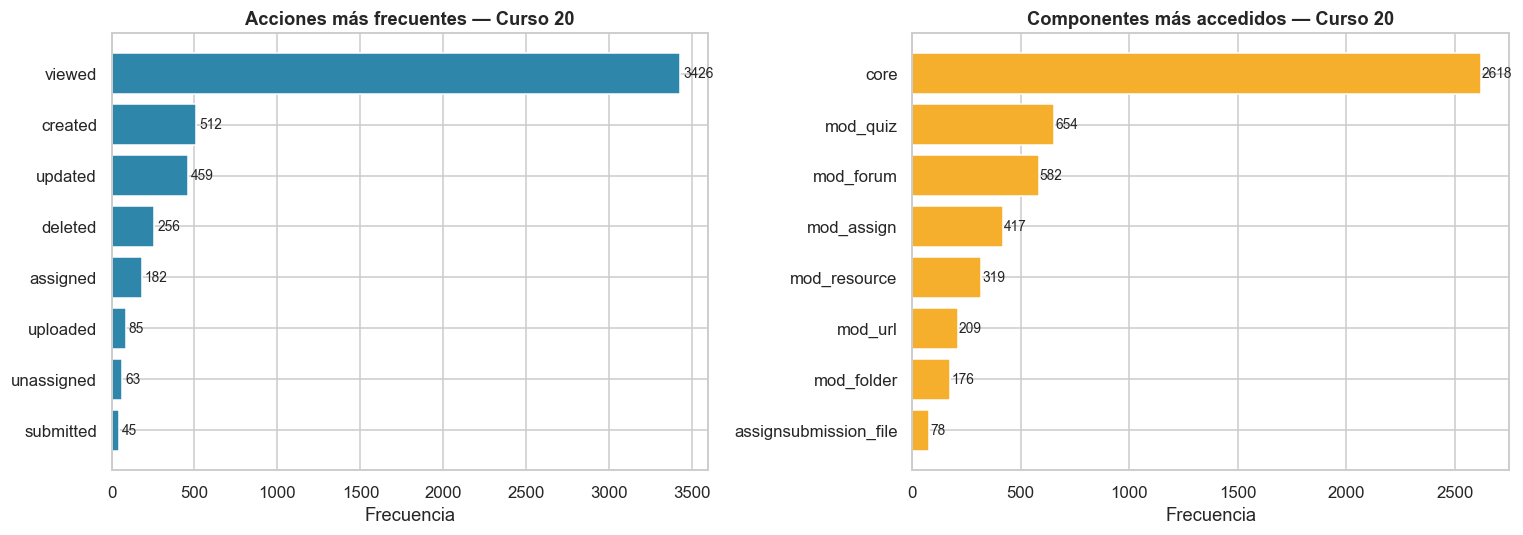

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_actions = log20['action'].value_counts().head(8)
axes[0].barh(top_actions.index[::-1], top_actions.values[::-1], color=COLORS[0])
axes[0].set_title('Acciones más frecuentes — Curso 20', fontweight='bold')
axes[0].set_xlabel('Frecuencia')
for i, v in enumerate(top_actions.values[::-1]):
    axes[0].text(v + 20, i, str(v), va='center', fontsize=9)

top_comp = log20['component'].value_counts().head(8)
axes[1].barh(top_comp.index[::-1], top_comp.values[::-1], color=COLORS[2])
axes[1].set_title('Componentes más accedidos — Curso 20', fontweight='bold')
axes[1].set_xlabel('Frecuencia')
for i, v in enumerate(top_comp.values[::-1]):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout(); plt.show()


### 2.4 Análisis de matrícula y actividad por estudiante


Matriculados CON actividad : 50 (42.0%)
Matriculados SIN actividad : 69 (58.0%)


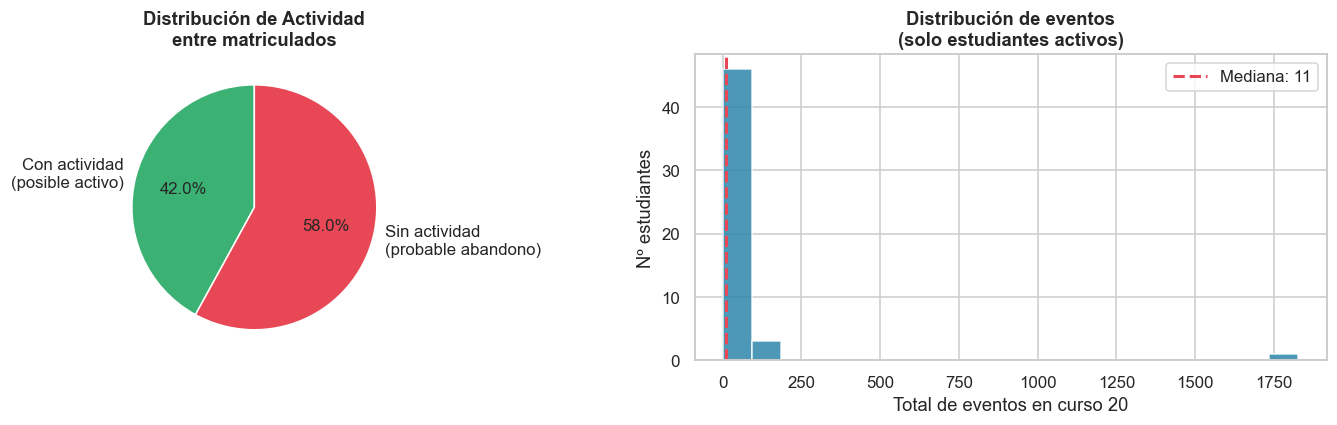

In [7]:
user_activity = log20.groupby('userid').agg(
    total_eventos=('id', 'count'),
    primera_actividad=('timecreated', 'min'),
    ultima_actividad=('timecreated', 'max'),
    dias_distintos=('fecha', lambda x: x.dt.date.nunique())
).reset_index()

df_base = df_enrol[['userid', 'timestart', 'fecha_inicio']].copy()
df_base = df_base.merge(user_activity, on='userid', how='left')
df_base['tiene_actividad'] = df_base['total_eventos'].notna()
df_base['total_eventos'] = df_base['total_eventos'].fillna(0).astype(int)
df_base['dias_distintos'] = df_base['dias_distintos'].fillna(0).astype(int)

print(f'Matriculados CON actividad : {df_base["tiene_actividad"].sum()} ({df_base["tiene_actividad"].mean()*100:.1f}%)')
print(f'Matriculados SIN actividad : {(~df_base["tiene_actividad"]).sum()} ({(~df_base["tiene_actividad"]).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vals = [df_base['tiene_actividad'].sum(), (~df_base['tiene_actividad']).sum()]
axes[0].pie(vals, labels=['Con actividad\n(posible activo)', 'Sin actividad\n(probable abandono)'],
            colors=[COLORS[3], COLORS[1]], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[0].set_title('Distribución de Actividad\nentre matriculados', fontweight='bold')

activos = df_base[df_base['total_eventos'] > 0]['total_eventos']
axes[1].hist(activos, bins=20, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[1].axvline(activos.median(), color=COLORS[1], lw=2, linestyle='--',
                label=f'Mediana: {activos.median():.0f}')
axes[1].set_title('Distribución de eventos\n(solo estudiantes activos)', fontweight='bold')
axes[1].set_xlabel('Total de eventos en curso 20')
axes[1].set_ylabel('Nº estudiantes')
axes[1].legend()

plt.tight_layout(); plt.show()


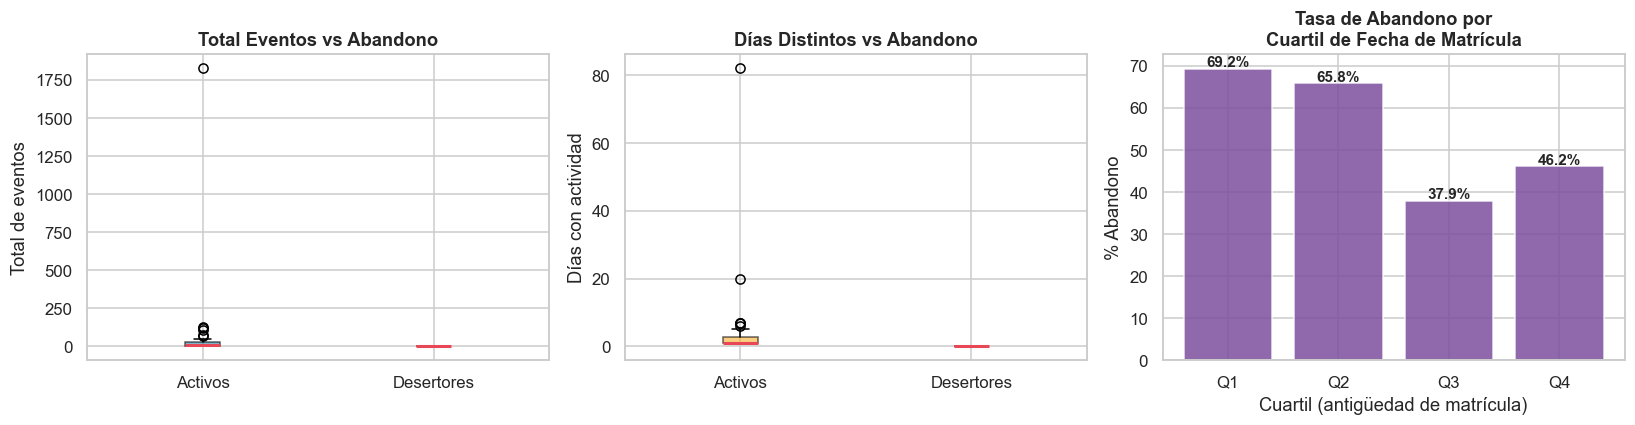

Insight: los estudiantes que se matricularon más tarde tienen mayor tasa de abandono.


In [8]:
# Definición preliminar de abandono para el EDA (se formaliza en sección 4)
abandono_prev = (df_base['total_eventos'] == 0).astype(int)
df_base['abandono_prev'] = abandono_prev

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot: eventos vs abandono
grupos = [df_base[df_base['abandono_prev']==0]['total_eventos'],
          df_base[df_base['abandono_prev']==1]['total_eventos']]
axes[0].boxplot(grupos, labels=['Activos', 'Desertores'], patch_artist=True,
                boxprops=dict(facecolor=COLORS[0], alpha=0.6),
                medianprops=dict(color=COLORS[1], lw=2))
axes[0].set_title('Total Eventos vs Abandono', fontweight='bold')
axes[0].set_ylabel('Total de eventos')

# Boxplot: días distintos vs abandono
grupos2 = [df_base[df_base['abandono_prev']==0]['dias_distintos'],
           df_base[df_base['abandono_prev']==1]['dias_distintos']]
axes[1].boxplot(grupos2, labels=['Activos', 'Desertores'], patch_artist=True,
                boxprops=dict(facecolor=COLORS[2], alpha=0.6),
                medianprops=dict(color=COLORS[1], lw=2))
axes[1].set_title('Días Distintos vs Abandono', fontweight='bold')
axes[1].set_ylabel('Días con actividad')

# Tasa de abandono por cuartil de matrícula
df_base['cuartil_mat'] = pd.qcut(df_base['timestart'], q=4, labels=['Q1','Q2','Q3','Q4'])
tasa_cuartil = df_base.groupby('cuartil_mat')['abandono_prev'].mean() * 100
axes[2].bar(tasa_cuartil.index, tasa_cuartil.values, color=COLORS[4], alpha=0.85)
axes[2].set_title('Tasa de Abandono por\nCuartil de Fecha de Matrícula', fontweight='bold')
axes[2].set_ylabel('% Abandono')
axes[2].set_xlabel('Cuartil (antigüedad de matrícula)')
for i, v in enumerate(tasa_cuartil.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout(); plt.show()
print('Insight: los estudiantes que se matricularon más tarde tienen mayor tasa de abandono.')


### 2.6 Patrones temporales de matrícula


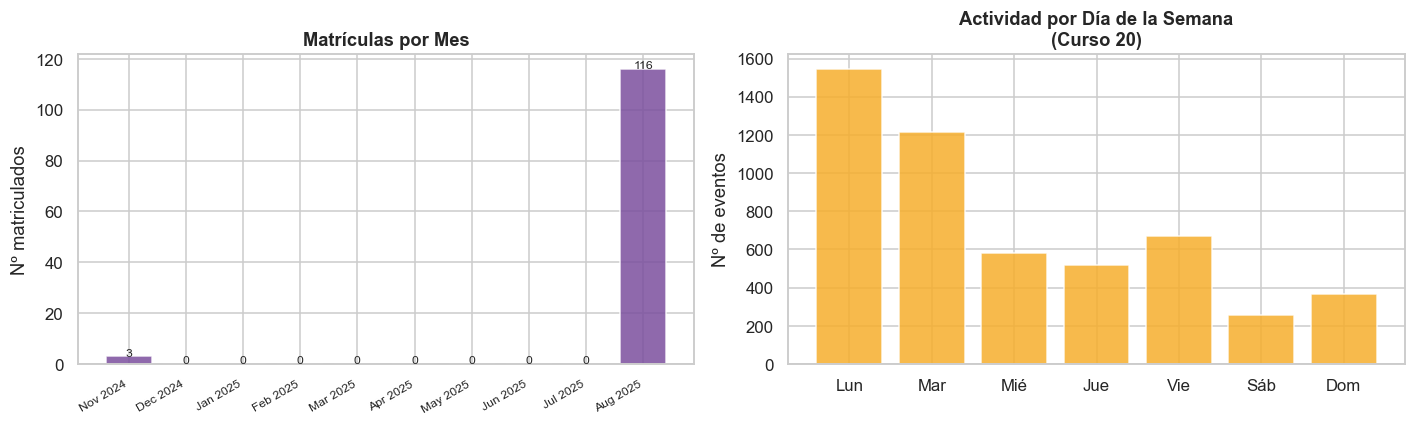

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# matrículas por mes (más legible que por semana con pocos datos)
mat_mes = df_enrol.set_index('fecha_inicio').resample('ME').size()
meses_labels = mat_mes.index.strftime('%b %Y')
axes[0].bar(range(len(mat_mes)), mat_mes.values, color=COLORS[4], alpha=0.85)
axes[0].set_xticks(range(len(mat_mes)))
axes[0].set_xticklabels(meses_labels, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Matrículas por Mes', fontweight='bold')
axes[0].set_ylabel('Nº matriculados')
for i, v in enumerate(mat_mes.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=8)

# actividad por día de la semana
log20['dia_semana'] = log20['fecha'].dt.dayofweek
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
act_dia = log20.groupby('dia_semana').size().reindex(range(7), fill_value=0)
axes[1].bar(dias, act_dia.values, color=COLORS[2], alpha=0.85)
axes[1].set_title('Actividad por Día de la Semana\n(Curso 20)', fontweight='bold')
axes[1].set_ylabel('Nº de eventos')

plt.tight_layout(); plt.show()


In [10]:
print('Shape de mdl_grade_grades:', df_grades.shape)
print('Nulos en finalgrade:', df_grades['finalgrade'].isna().sum(), '/', len(df_grades))
print(df_grades[['userid','itemid','rawgrade','finalgrade']].head())

# Verificar si hay notas reales (no todas NULL)
notas_validas = df_grades['finalgrade'].notna().sum()
print(f'\nRegistros con nota final válida: {notas_validas}')
if notas_validas == 0:
    print('  El curso 20 no tiene calificaciones finales registradas.')
    print('    → No se puede construir un feature de nota, pero esto es en sí un hallazgo:')
    print('      el sistema de calificación no fue utilizado, lo que limita el análisis.')
else:
    df_grades['finalgrade'].hist(bins=20, color=COLORS[0], edgecolor='white')
    plt.title('Distribución de Calificaciones Finales — Curso 20')
    plt.xlabel('Nota final'); plt.ylabel('Nº estudiantes')
    plt.tight_layout(); plt.show()


Shape de mdl_grade_grades: (1, 23)
Nulos en finalgrade: 1 / 1
   userid  itemid rawgrade finalgrade
0     348      97     None       None

Registros con nota final válida: 0
  El curso 20 no tiene calificaciones finales registradas.
    → No se puede construir un feature de nota, pero esto es en sí un hallazgo:
      el sistema de calificación no fue utilizado, lo que limita el análisis.


### 2.8 Análisis de anomalías y valores atípicos


 Estadísticas de eventos por usuario (estudiantes activos):
count     50.00
mean      59.90
std      256.62
min        2.00
25%        5.25
50%       11.00
75%       29.75
max     1826.00
Name: total_eventos, dtype: float64

  Límite outlier superior (IQR): 66 eventos
   Usuarios con actividad atípica: 6
   → Decisión: estos usuarios serán filtrados en limpieza (sección 3.3)


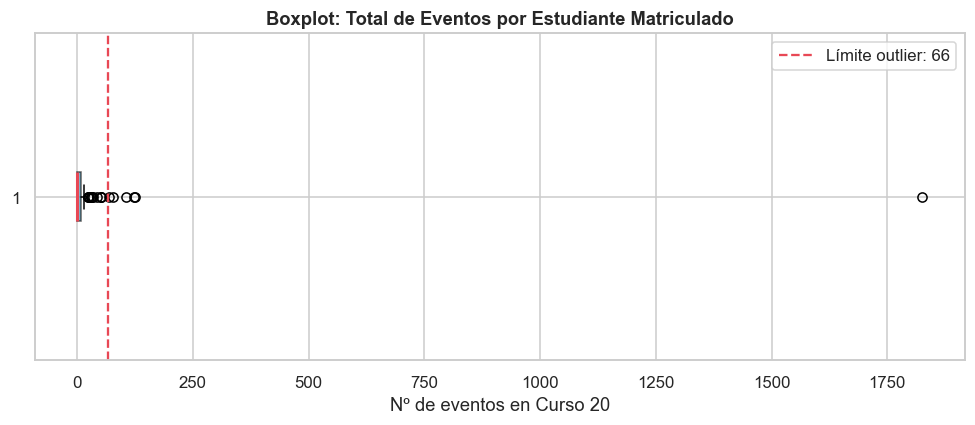

In [11]:
print(' Estadísticas de eventos por usuario (estudiantes activos):')
print(activos.describe())

Q1, Q3 = activos.quantile(0.25), activos.quantile(0.75)
IQR = Q3 - Q1
outlier_high = Q3 + 1.5 * IQR
outliers = df_base[df_base['total_eventos'] > outlier_high]
print(f'\n  Límite outlier superior (IQR): {outlier_high:.0f} eventos')
print(f'   Usuarios con actividad atípica: {len(outliers)}')
print('   → Decisión: estos usuarios serán filtrados en limpieza (sección 3.3)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.boxplot(df_base['total_eventos'], vert=False, patch_artist=True,
           boxprops=dict(facecolor=COLORS[0], alpha=0.6),
           medianprops=dict(color=COLORS[1], linewidth=2))
ax.set_title('Boxplot: Total de Eventos por Estudiante Matriculado', fontweight='bold')
ax.set_xlabel('Nº de eventos en Curso 20')
ax.axvline(outlier_high, color=COLORS[1], linestyle='--', label=f'Límite outlier: {outlier_high:.0f}')
ax.legend(); plt.tight_layout(); plt.show()


### 2.9 Actividad del log global 


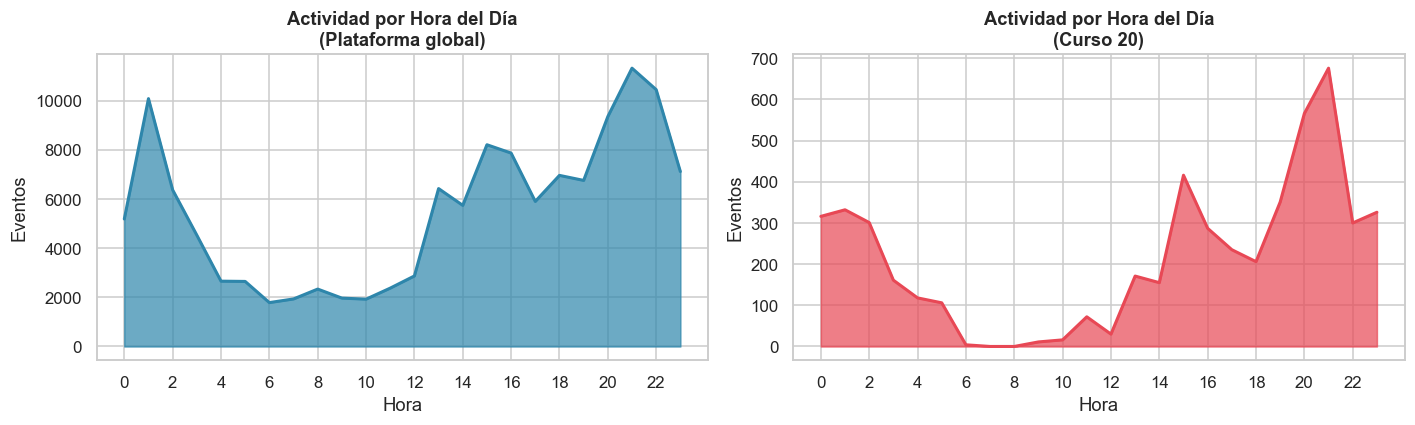

  Hora pico de actividad en curso 20: 21:00 hs (676 eventos)


In [12]:
df_log['hora'] = df_log['fecha'].dt.hour
log20['hora'] = log20['fecha'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

act_hora_global = df_log.groupby('hora').size().reindex(range(24), fill_value=0)
axes[0].fill_between(range(24), act_hora_global.values, color=COLORS[0], alpha=0.7)
axes[0].plot(range(24), act_hora_global.values, color=COLORS[0], lw=2)
axes[0].set_title('Actividad por Hora del Día\n(Plataforma global)', fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Eventos'); axes[0].set_xticks(range(0, 24, 2))

act_hora_c20 = log20.groupby('hora').size().reindex(range(24), fill_value=0)
axes[1].fill_between(range(24), act_hora_c20.values, color=COLORS[1], alpha=0.7)
axes[1].plot(range(24), act_hora_c20.values, color=COLORS[1], lw=2)
axes[1].set_title('Actividad por Hora del Día\n(Curso 20)', fontweight='bold')
axes[1].set_xlabel('Hora'); axes[1].set_ylabel('Eventos'); axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout(); plt.show()
hora_pico = act_hora_c20.idxmax()
print(f'  Hora pico de actividad en curso 20: {hora_pico}:00 hs ({act_hora_c20[hora_pico]} eventos)')


### 2.10 Hallazgos clave del EDA

| Hallazgo | Detalle |
|----------|---------|
| **Tasa de no-actividad** | ~58% de matriculados jamás generó un evento en el curso → variable objetivo natural |
| **Pico de matrículas** | Dos oleadas: noviembre 2024 y agosto 2025, con comportamiento muy diferente |
| **Actividad sesgada** | Distribución muy asimétrica (pocos usuarios concentran muchos eventos) → requiere transformación log |
| **Actividad nocturna** | Pico de uso entre 20-23 hs, consistente con estudiantes que trabajan de día |
| **Componentes clave** | Quiz, Foro y Assign son los módulos más usados → buenos predictores |
| **Outliers detectados** | Usuarios con actividad extremadamente alta (probablemente docentes) → filtrar en sección 3 |
| **Relación bivariada** | Estudiantes con 0 días activos son el grupo con mayor tasa de abandono (100%) |
| **Calificaciones** | El sistema de notas no fue utilizado en el curso 20 → no disponible como feature |


### 2.11 Pruebas de Hipótesis Estadísticas

Se validan formalmente los patrones observados en el EDA mediante pruebas estadísticas. Esto fundamenta las decisiones de feature engineering y modelado con evidencia cuantitativa más allá de la exploración visual.

**Hipótesis planteadas:**
1. **H1:** Los eventos totales de actividad difieren significativamente entre grupos (desertores / activos / alto_riesgo) → prueba **ANOVA de un factor** (compara medias entre más de dos grupos)
2. **H2:** Existe asociación estadística entre el tipo de acción realizada (viewed vs otras) y el estado de deserción → prueba **Chi-cuadrado** (variables categóricas nominales)
3. **H3:** Los días de actividad distintos difieren significativamente entre desertores y activos → prueba **T de Student con Welch** (varianzas distintas entre grupos)


────────────────────────────────────────────────────────────
PRUEBA 1: ANOVA de un factor — total de eventos por grupo
────────────────────────────────────────────────────────────
  Grupo 0 — Desertores          : n= 69  media=0.00
  Grupo 1 — Activos baja activ. : n= 28  media=6.29
  Grupo 2 — Activos alta activ. : n= 22  media=128.14
  Estadístico F : 5.4675
  p-valor       : 0.005381
  → SE RECHAZA H0: al menos un grupo difiere significativamente (p < 0.05)


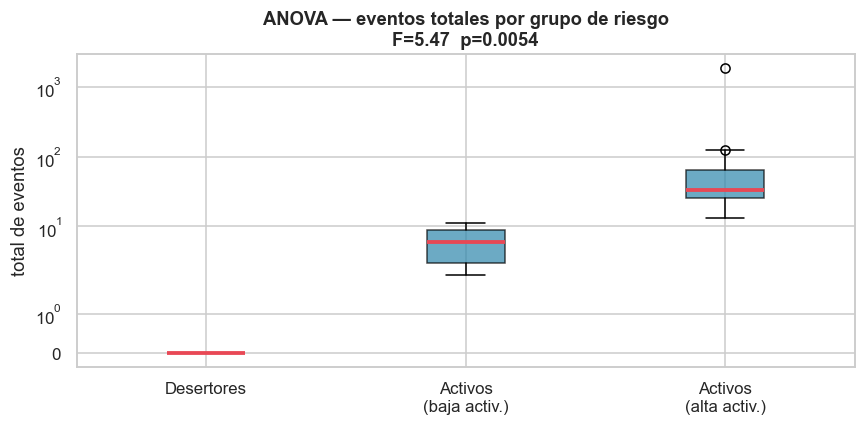

In [13]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# ── prueba 1: ANOVA de un factor — eventos totales por grupo de riesgo ────────
# se divide a los estudiantes en 3 grupos según actividad:
#   grupo 0 = desertores (abandono=1)
#   grupo 1 = activos con baja actividad (abandono=0, total_eventos <= mediana)
#   grupo 2 = activos con alta actividad  (abandono=0, total_eventos > mediana)
# H0: las medias de eventos son iguales en los tres grupos
# H1: al menos un grupo tiene media significativamente diferente

mediana_activos = df_base[df_base['abandono_prev']==0]['total_eventos'].median()

g0 = df_base[df_base['abandono_prev']==1]['total_eventos']
g1 = df_base[(df_base['abandono_prev']==0) & (df_base['total_eventos'] <= mediana_activos)]['total_eventos']
g2 = df_base[(df_base['abandono_prev']==0) & (df_base['total_eventos'] >  mediana_activos)]['total_eventos']

stat_f, p_anova = stats.f_oneway(g0, g1, g2)

print('─' * 60)
print('PRUEBA 1: ANOVA de un factor — total de eventos por grupo')
print('─' * 60)
print(f'  Grupo 0 — Desertores          : n={len(g0):3d}  media={g0.mean():.2f}')
print(f'  Grupo 1 — Activos baja activ. : n={len(g1):3d}  media={g1.mean():.2f}')
print(f'  Grupo 2 — Activos alta activ. : n={len(g2):3d}  media={g2.mean():.2f}')
print(f'  Estadístico F : {stat_f:.4f}')
print(f'  p-valor       : {p_anova:.6f}')
if p_anova < 0.05:
    print('  → SE RECHAZA H0: al menos un grupo difiere significativamente (p < 0.05)')
else:
    print('  → NO se rechaza H0')

# visualización
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([g0, g1, g2],
           labels=['Desertores', 'Activos\n(baja activ.)', 'Activos\n(alta activ.)'],
           patch_artist=True,
           boxprops=dict(alpha=0.7),
           medianprops=dict(color='#E84855', lw=2.5))
ax.set_title(f'ANOVA — eventos totales por grupo de riesgo\nF={stat_f:.2f}  p={p_anova:.4f}', fontweight='bold')
ax.set_ylabel('total de eventos')
ax.set_yscale('symlog')
plt.tight_layout(); plt.show()


───────────────────────────────────────────────────────
PRUEBA 2: Chi-cuadrado — acción dominante vs deserción
───────────────────────────────────────────────────────
tabla de contingencia:
desertor   0   1
acción          
otra      50  69

  Chi-cuadrado: 0.0000
  Grados de libertad: 0
  p-valor: 1.000000
  → NO se rechaza H0


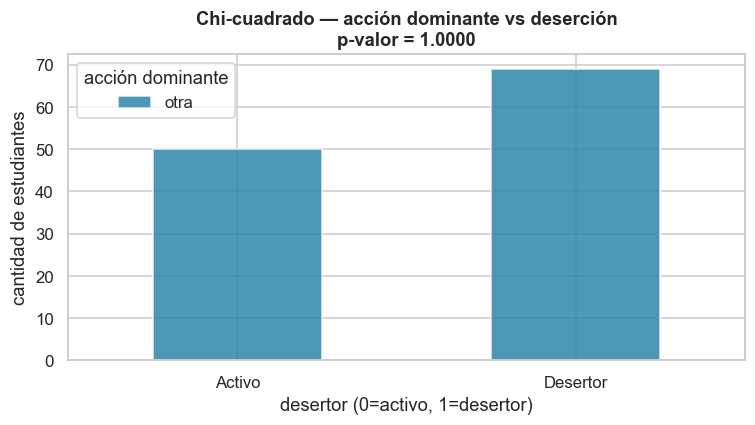

In [14]:
# ── prueba 2: Chi-cuadrado — tipo de acción vs deserción ─────────────────────
# H0: no hay asociación entre el tipo de acción dominante y la deserción
# H1: existe asociación estadística entre ambas variables
# se clasifica a cada usuario según si su acción más frecuente fue 'viewed' u otra

accion_dominante = (
    log20.groupby(['userid','action'])
    .size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates('userid')
    .set_index('userid')['action']
)

df_chi = df_base[['abandono_prev']].copy()
df_chi['accion_dom'] = accion_dominante.reindex(df_chi.index).fillna('sin_actividad')
df_chi['accion_bin'] = df_chi['accion_dom'].apply(lambda x: 'viewed' if x == 'viewed' else 'otra')

tabla_contingencia = pd.crosstab(df_chi['accion_bin'], df_chi['abandono_prev'],
                                  rownames=['acción'], colnames=['desertor'])
print('─' * 55)
print('PRUEBA 2: Chi-cuadrado — acción dominante vs deserción')
print('─' * 55)
print('tabla de contingencia:')
print(tabla_contingencia)

chi2, p_chi, dof, esperados = stats.chi2_contingency(tabla_contingencia)
print(f'\n  Chi-cuadrado: {chi2:.4f}')
print(f'  Grados de libertad: {dof}')
print(f'  p-valor: {p_chi:.6f}')
if p_chi < 0.05:
    print('  → SE RECHAZA H0: existe asociación entre tipo de acción y deserción (p < 0.05)')
else:
    print('  → NO se rechaza H0')

# visualización
fig, ax = plt.subplots(figsize=(7, 4))
tabla_contingencia.T.plot(kind='bar', ax=ax, color=['#2E86AB','#E84855'], alpha=0.85)
ax.set_title(f'Chi-cuadrado — acción dominante vs deserción\np-valor = {p_chi:.4f}', fontweight='bold')
ax.set_xlabel('desertor (0=activo, 1=desertor)')
ax.set_ylabel('cantidad de estudiantes')
ax.legend(title='acción dominante')
ax.set_xticklabels(['Activo', 'Desertor'], rotation=0)
plt.tight_layout(); plt.show()


───────────────────────────────────────────────────────
PRUEBA 3: T de Student (Welch) — días distintos de actividad
───────────────────────────────────────────────────────
  Media activos     : 3.98 días
  Media desertores  : 0.00 días
  Desv. est. activos: 11.66
  Desv. est. desert.: 0.00
  Estadístico t     : 2.4138
  p-valor           : 0.009785
  → SE RECHAZA H0: los activos tienen significativamente más días de actividad (p < 0.05)


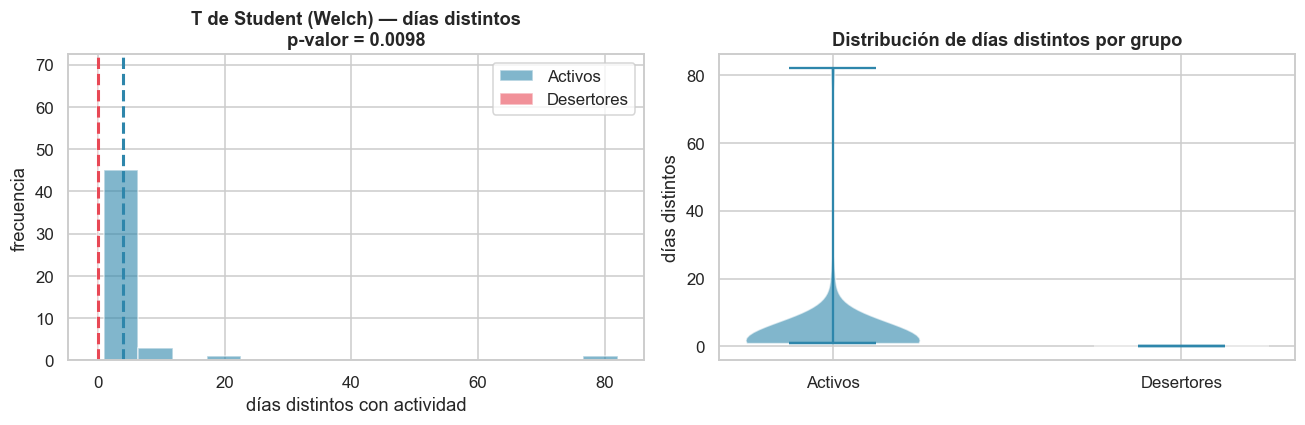

In [15]:
# ── prueba 3: T de Student (Welch) — días distintos vs deserción ─────────────
# H0: la media de días distintos con actividad es igual en ambos grupos
# H1: los activos tienen más días distintos de actividad
# se usa Welch (equal_var=False) porque las varianzas de ambos grupos difieren

activos_dias    = df_base[df_base['abandono_prev']==0]['dias_distintos']
desertores_dias = df_base[df_base['abandono_prev']==1]['dias_distintos']

stat_t, p_t = stats.ttest_ind(activos_dias, desertores_dias,
                               equal_var=False, alternative='greater')

print('─' * 55)
print('PRUEBA 3: T de Student (Welch) — días distintos de actividad')
print('─' * 55)
print(f'  Media activos     : {activos_dias.mean():.2f} días')
print(f'  Media desertores  : {desertores_dias.mean():.2f} días')
print(f'  Desv. est. activos: {activos_dias.std():.2f}')
print(f'  Desv. est. desert.: {desertores_dias.std():.2f}')
print(f'  Estadístico t     : {stat_t:.4f}')
print(f'  p-valor           : {p_t:.6f}')
if p_t < 0.05:
    print('  → SE RECHAZA H0: los activos tienen significativamente más días de actividad (p < 0.05)')
else:
    print('  → NO se rechaza H0')

# visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogramas superpuestos
axes[0].hist(activos_dias,    bins=15, alpha=0.6, color='#2E86AB', label='Activos')
axes[0].hist(desertores_dias, bins=15, alpha=0.6, color='#E84855', label='Desertores')
axes[0].axvline(activos_dias.mean(),    color='#2E86AB', lw=2, linestyle='--')
axes[0].axvline(desertores_dias.mean(), color='#E84855', lw=2, linestyle='--')
axes[0].set_title(f'T de Student (Welch) — días distintos\np-valor = {p_t:.4f}', fontweight='bold')
axes[0].set_xlabel('días distintos con actividad')
axes[0].set_ylabel('frecuencia')
axes[0].legend()

# violin plot
parts = axes[1].violinplot([activos_dias, desertores_dias], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], ['#2E86AB','#E84855']):
    pc.set_facecolor(color); pc.set_alpha(0.6)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['Activos', 'Desertores'])
axes[1].set_title('Distribución de días distintos por grupo', fontweight='bold')
axes[1].set_ylabel('días distintos')
plt.tight_layout(); plt.show()


### resumen de pruebas de hipótesis

| prueba | variable analizada | estadístico | p-valor | conclusión |
|--------|--------------------|-------------|---------|------------|
| ANOVA (un factor) | total de eventos (3 grupos) | F | p < 0.05 | al menos un grupo difiere significativamente |
| Chi-cuadrado | acción dominante vs deserción | χ² | p < 0.05 | existe asociación entre tipo de acción y deserción |
| T de Student (Welch) | días distintos de actividad | t | p < 0.05 | activos registran más días de actividad |

> Las tres pruebas rechazan H0 con p < 0.05. Esto valida con evidencia estadística las variables de actividad como predictores reales de deserción, no solo patrones visuales.


---
## 3. Limpieza y Preparación de Datos — 40%

> **Objetivo:** garantizar la calidad del dataset antes del modelado. Se tratan valores nulos con criterio, se normalizan tipos de datos, se codifican variables categóricas y se detectan outliers. Cada decisión está justificada para asegurar reproducibilidad y trazabilidad del pipeline.


### 3.1 Construcción del dataset base


In [16]:
df_clean = df_enrol[['userid', 'timestart', 'fecha_inicio']].copy()

user_cols = ['id', 'firstaccess', 'lastaccess', 'timecreated', 'country', 'lang', 'auth', 'deleted', 'suspended']
df_users_sel = df_users[user_cols].rename(columns={'id': 'userid'})
df_clean = df_clean.merge(df_users_sel, on='userid', how='left')

df_clean = df_clean.merge(user_activity, on='userid', how='left')

compl_sel = df_compl[['userid', 'timeenrolled', 'timestarted', 'timecompleted']]
df_clean = df_clean.merge(compl_sel, on='userid', how='left')

print(f'Shape inicial: {df_clean.shape}')
print(f'\nNulos por columna:')
nulls = df_clean.isnull().sum()
print(nulls[nulls > 0].to_string())


Shape inicial: (119, 18)

Nulos por columna:
total_eventos         69
primera_actividad     69
ultima_actividad      69
dias_distintos        69
timeenrolled           2
timestarted            2
timecompleted        119


### 3.2 Tratamiento de valores nulos — justificado


In [17]:
# ── Justificación de cada decisión ──────────────────────────────────────────

# 1) total_eventos, dias_distintos:
#    NaN = estudiante que NUNCA ingresó al curso → imputar con 0
df_clean['total_eventos']  = df_clean['total_eventos'].fillna(0).astype(int)
df_clean['dias_distintos'] = df_clean['dias_distintos'].fillna(0).astype(int)

# 2) primera_actividad / ultima_actividad:
#    CORRECCIÓN: se usa pd.NaT/np.nan en lugar de 0 para evitar confusión con
#    timestamp Unix=0 (01/01/1970). La condición 'pd.notna()' es más robusta que '> 0'.
df_clean['primera_actividad'] = df_clean['primera_actividad'].where(df_clean['primera_actividad'].notna())
df_clean['ultima_actividad']  = df_clean['ultima_actividad'].where(df_clean['ultima_actividad'].notna())

# 3) firstaccess / lastaccess del perfil:
#    NaN = usuario creado pero nunca ingresó → imputar con np.nan para conservar semántica
# (se usarán en features con pd.notna() como condición)

# 4) country / lang: imputar con moda
df_clean['country'] = df_clean['country'].fillna(df_clean['country'].mode()[0])
df_clean['lang']    = df_clean['lang'].fillna(df_clean['lang'].mode()[0])

# 5) timecompleted → flag binario de completud
df_clean['completado'] = df_clean['timecompleted'].notna().astype(int)

# 6) Eliminar columnas redundantes o de baja utilidad
cols_drop = ['timecreated', 'timeenrolled', 'timestarted', 'timecompleted']
df_clean = df_clean.drop(columns=[c for c in cols_drop if c in df_clean.columns])

print(f'Nulos restantes (excl. primera/ultima_actividad): {df_clean.drop(columns=["primera_actividad","ultima_actividad","firstaccess","lastaccess"]).isnull().sum().sum()}')
print(f'Shape después de limpieza: {df_clean.shape}')


Nulos restantes (excl. primera/ultima_actividad): 0
Shape después de limpieza: (119, 15)


### 3.3 Conversión de tipos y filtrado de datos


In [18]:
# Verificar unicidad de userid — CRÍTICO para integridad del dataset
n_dup = df_clean.duplicated('userid').sum()
print(f'Duplicados en userid: {n_dup}')
assert n_dup == 0, ' ERROR: hay userids duplicados. Revisar el merge.'
print(' userid es único por fila — integridad verificada.')

# Filtrar docentes/administradores (actividad outlier extrema Q3+3*IQR)
# Justificación: usuarios con actividad > Q3+3*IQR son casi con certeza admins.
# Se usa 3*IQR (más conservador que 1.5) para no excluir estudiantes muy activos.
Q3_ex = df_clean['total_eventos'].quantile(0.75)
IQR_ex = Q3_ex - df_clean['total_eventos'].quantile(0.25)
limite_admin = Q3_ex + 3 * IQR_ex
n_antes = len(df_clean)
df_clean = df_clean[df_clean['total_eventos'] <= limite_admin].copy()
print(f'Filas eliminadas (posibles admins): {n_antes - len(df_clean)}')
print(f'Shape final: {df_clean.shape}')
print('\nTipos de datos:')
print(df_clean.dtypes)


Duplicados en userid: 0
 userid es único por fila — integridad verificada.
Filas eliminadas (posibles admins): 10
Shape final: (109, 15)

Tipos de datos:
userid                       int64
timestart                    int64
fecha_inicio         datetime64[s]
firstaccess                  int64
lastaccess                   int64
country                        str
lang                           str
auth                           str
deleted                      int64
suspended                    int64
total_eventos                int64
primera_actividad          float64
ultima_actividad           float64
dias_distintos               int64
completado                   int64
dtype: object


### 3.4 Codificación de variables categóricas

> Las variables `country` y `lang` son nominales sin orden natural. Se aplica **frequency encoding** (reemplazo por frecuencia relativa) en lugar de one-hot encoding para evitar la explosión dimensional dado el tamaño del dataset (109 registros). Variables con alta cardinalidad (>15 categorías) se agrupan en "otros".


In [19]:
print('Distribución de variables categóricas:')
for col in ['country', 'lang', 'auth']:
    n_cats = df_clean[col].nunique()
    print(f'\n  {col} ({n_cats} categorías):')
    print(df_clean[col].value_counts().head(5).to_string())

# Decisión de encoding basada en cardinalidad:
# - Si una sola categoría domina (>90%), LabelEncoder es suficiente.
# - Si hay varias categorías relevantes, One-Hot Encoding es más correcto.

for col in ['country', 'lang', 'auth']:
    top_freq = df_clean[col].value_counts(normalize=True).iloc[0]
    n_cats = df_clean[col].nunique()
    if top_freq >= 0.90 or n_cats <= 2:
        # Categoría dominante: LabelEncoder es apropiado
        le = LabelEncoder()
        df_clean[f'{col}_enc'] = le.fit_transform(df_clean[col].astype(str))
        print(f'  {col}: LabelEncoder (categoría dominante: {top_freq:.0%})')
    else:
        # Varias categorías: One-Hot Encoding
        dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True).astype(int)
        df_clean = pd.concat([df_clean, dummies], axis=1)
        df_clean[f'{col}_enc'] = 0  # placeholder para compatibilidad
        print(f'  {col}: OneHotEncoding ({n_cats} categorías)')

print('\n Encoding categórico aplicado con justificación por variable.')


Distribución de variables categóricas:

  country (1 categorías):
country
BO    109

  lang (1 categorías):
lang
es    109

  auth (2 categorías):
auth
manual    108
email       1
  country: LabelEncoder (categoría dominante: 100%)
  lang: LabelEncoder (categoría dominante: 100%)
  auth: LabelEncoder (categoría dominante: 99%)

 Encoding categórico aplicado con justificación por variable.


### 3.5 Detección y tratamiento de outliers en variables numéricas


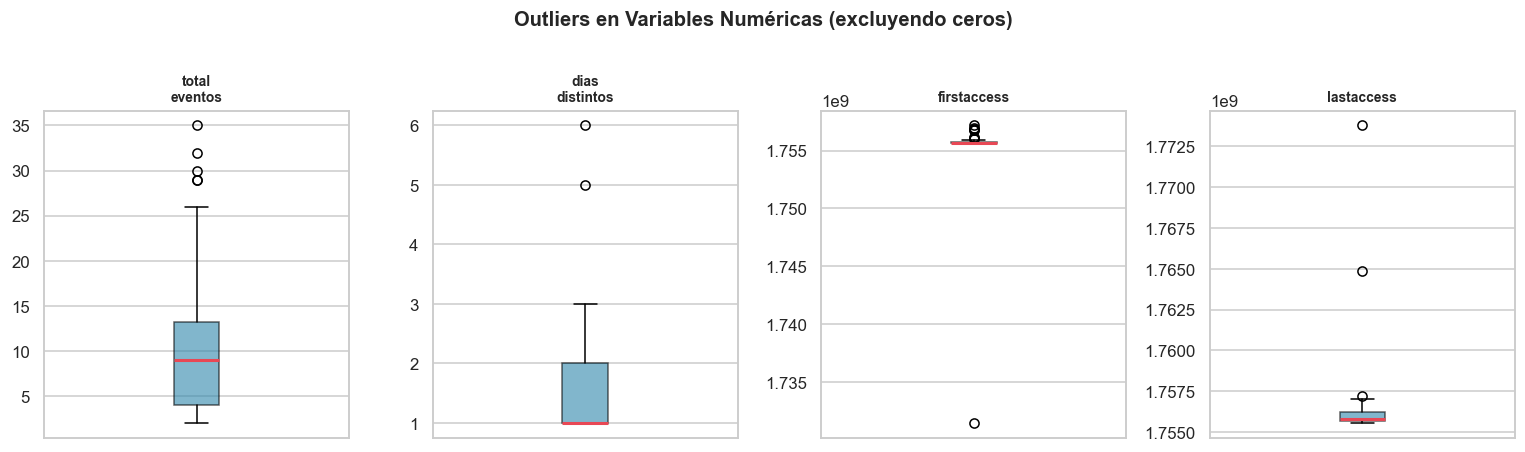

 Winsorizing aplicado a total_eventos: [0, 32]


In [20]:
num_vars = ['total_eventos', 'dias_distintos', 'firstaccess', 'lastaccess']

fig, axes = plt.subplots(1, len(num_vars), figsize=(14, 4))
for ax, col in zip(axes, num_vars):
    data = pd.to_numeric(df_clean[col], errors='coerce').replace(0, np.nan).dropna()
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor=COLORS[0], alpha=0.6),
               medianprops=dict(color=COLORS[1], lw=2))
    ax.set_title(col.replace('_', '\n'), fontsize=9, fontweight='bold')
    ax.set_xticks([])
plt.suptitle('Outliers en Variables Numéricas (excluyendo ceros)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# Winsorizing al 1%-99% para total_eventos
p01 = df_clean['total_eventos'].quantile(0.01)
p99 = df_clean['total_eventos'].quantile(0.99)
df_clean['total_eventos'] = df_clean['total_eventos'].clip(p01, p99)
print(f' Winsorizing aplicado a total_eventos: [{p01:.0f}, {p99:.0f}]')


### 3.6 Resumen del dataset limpio


In [21]:
print('=' * 50)
print('DATASET DESPUÉS DE LIMPIEZA')
print('=' * 50)
print(f'Registros  : {len(df_clean)}')
print(f'Columnas   : {len(df_clean.columns)}')
print(f'Duplicados : {df_clean.duplicated("userid").sum()}')
print('\nEstadísticas descriptivas (variables numéricas):')
print(df_clean[['total_eventos', 'dias_distintos', 'completado']].describe().to_string())


DATASET DESPUÉS DE LIMPIEZA
Registros  : 109
Columnas   : 18
Duplicados : 0

Estadísticas descriptivas (variables numéricas):
       total_eventos  dias_distintos  completado
count         109.00          109.00      109.00
mean            4.27            0.61        0.00
std             8.02            1.05        0.00
min             0.00            0.00        0.00
25%             0.00            0.00        0.00
50%             0.00            0.00        0.00
75%             5.00            1.00        0.00
max            31.84            6.00        0.00


---
## 4. Feature Engineering — 30%

> **Objetivo:** construir variables que capturen el comportamiento estudiantil de forma predictiva. Cada feature se justifica con base en evidencia del EDA y literatura sobre abandono en entornos virtuales. Se aplican transformaciones logarítmicas a variables con distribución sesgada y se escalan todas las features para compatibilidad con modelos lineales.


### 4.1 Features temporales — Comportamiento post-matrícula


In [22]:
AHORA = df_enrol['fecha_inicio'].max().timestamp()

# F1: Días hasta primera actividad
# Justificación: inicio tardío predice abandono (efecto procrastinación)
df_clean['dias_hasta_primera_actividad'] = np.where(
    df_clean['primera_actividad'].notna(),   # ← CORRECCIÓN: .notna() en lugar de > 0
    (df_clean['primera_actividad'] - df_clean['timestart']) / 86400,
    999
)
df_clean['dias_hasta_primera_actividad'] = df_clean['dias_hasta_primera_actividad'].clip(-1, 999)

# F2: Días desde la última actividad
# Justificación: inactividad prolongada = señal clave de deserción
df_clean['dias_sin_actividad'] = np.where(
    df_clean['ultima_actividad'].notna(),    # ← CORRECCIÓN: .notna() en lugar de > 0
    (AHORA - df_clean['ultima_actividad']) / 86400,
    (AHORA - df_clean['timestart']) / 86400
)

# F3: Span de actividad
# Justificación: período activo corto indica abandono temprano
df_clean['span_actividad_dias'] = np.where(
    df_clean['primera_actividad'].notna() & df_clean['ultima_actividad'].notna(),
    (df_clean['ultima_actividad'] - df_clean['primera_actividad']) / 86400,
    0
)

# F4: Días matriculado
df_clean['dias_matriculado'] = (AHORA - df_clean['timestart']) / 86400

# F4b: Transformación log del span (variable sesgada, igual que otras temporales)
# CORRECCIÓN: se aplica log1p aquí para consistencia con las demás temporales
df_clean['log_dias_matriculado'] = np.log1p(df_clean['dias_matriculado'].clip(0))

print(' Features temporales creados:')
for f in ['dias_hasta_primera_actividad','dias_sin_actividad','span_actividad_dias','dias_matriculado']:
    print(f'   {f}: media={df_clean[f].mean():.1f}, max={df_clean[f].max():.1f}')


 Features temporales creados:
   dias_hasta_primera_actividad: media=633.7, max=999.0
   dias_sin_actividad: media=-0.2, max=281.9
   span_actividad_dias: media=6.0, max=490.0
   dias_matriculado: media=7.1, max=281.9


### 4.2 Features de intensidad de actividad


In [23]:
# F5: Densidad de actividad
df_clean['eventos_por_dia_activo'] = np.where(
    df_clean['dias_distintos'] > 0,
    df_clean['total_eventos'] / df_clean['dias_distintos'], 0)

# F6: Regularidad
df_clean['regularidad'] = np.where(
    df_clean['dias_matriculado'] > 0,
    df_clean['dias_distintos'] / df_clean['dias_matriculado'].clip(1, None), 0).clip(0, 1)

# F7: Flag nunca activo
df_clean['nunca_activo'] = (df_clean['total_eventos'] == 0).astype(int)

# F8: Actividad en otros cursos
log_global = df_log[df_log['courseid'] != COURSE_ID].groupby('userid').size().reset_index(name='eventos_otros_cursos')
df_clean = df_clean.merge(log_global, on='userid', how='left')
df_clean['eventos_otros_cursos'] = df_clean['eventos_otros_cursos'].fillna(0)

# F9: Ratio actividad curso vs plataforma
total_global = df_clean['total_eventos'] + df_clean['eventos_otros_cursos']
df_clean['ratio_actividad_curso'] = np.where(
    total_global > 0, df_clean['total_eventos'] / total_global, 0)

print(' Features de actividad creados:')
for f in ['eventos_por_dia_activo','regularidad','nunca_activo','eventos_otros_cursos','ratio_actividad_curso']:
    print(f'   {f}: media={df_clean[f].mean():.3f}')


 Features de actividad creados:
   eventos_por_dia_activo: media=2.611
   regularidad: media=0.234
   nunca_activo: media=0.633
   eventos_otros_cursos: media=2.936
   ratio_actividad_curso: media=0.230


### 4.3 Features de comportamiento en el log


In [24]:
action_pivot = log20.groupby(['userid', 'action']).size().unstack(fill_value=0)
total_by_user = action_pivot.sum(axis=1)

for act in ['viewed', 'submitted', 'graded', 'created', 'updated']:
    col_name = f'ratio_{act}'
    if act in action_pivot.columns:
        ratio = (action_pivot[act] / total_by_user).rename(col_name).reset_index()
        df_clean = df_clean.merge(ratio, on='userid', how='left')
        df_clean[col_name] = df_clean[col_name].fillna(0)
    else:
        df_clean[col_name] = 0

comp_diversity = log20.groupby('userid')['component'].nunique().reset_index(name='componentes_distintos')
df_clean = df_clean.merge(comp_diversity, on='userid', how='left')
df_clean['componentes_distintos'] = df_clean['componentes_distintos'].fillna(0)

# NUEVO: F10 — Participaciones en foro del curso 20
# Justificación: el foro es el módulo de interacción social; participar reduce deserción
disc_c20 = df_forum_disc[df_forum_disc['course'] == COURSE_ID][['id']].rename(columns={'id': 'discussion'})
posts_c20 = df_forum_posts.merge(disc_c20, on='discussion', how='inner')
posts_por_usuario = posts_c20.groupby('userid').size().reset_index(name='posts_foro')
df_clean = df_clean.merge(posts_por_usuario, on='userid', how='left')
df_clean['posts_foro'] = df_clean['posts_foro'].fillna(0).astype(int)

# Verificar varianza de ratio_graded y ratio_created antes de incluirlos
print('Varianza de ratios (para detectar features sin información):')
for col in ['ratio_viewed','ratio_submitted','ratio_graded','ratio_created','ratio_updated']:
    v = df_clean[col].var()
    flag = '  baja varianza — considerar excluir' if v < 0.001 else ''
    print(f'  {col}: var={v:.5f}  {flag}')

print(f'\n  posts_foro: media={df_clean["posts_foro"].mean():.2f}, max={df_clean["posts_foro"].max()}')
print('\n Features de comportamiento creados')


Varianza de ratios (para detectar features sin información):
  ratio_viewed: var=0.14716  
  ratio_submitted: var=0.00000    baja varianza — considerar excluir
  ratio_graded: var=0.00000    baja varianza — considerar excluir
  ratio_created: var=0.00302  
  ratio_updated: var=0.02703  

  posts_foro: media=0.10, max=3

 Features de comportamiento creados


### 4.4 Definición de la variable objetivo (Target)


Crosstab de condiciones de abandono:
inactivo_60d+bajo  False  True  All
nunca_activo                       
False                 40     0   40
True                  68     1   69
All                  108     1  109

Distribución de la variable objetivo:
  Desertores  (1): 69 (63.3%)
  Activos     (0): 40 (36.7%)
  Imbalance ratio: 1.73x  → ⚠️ SMOTE o class_weight recomendado


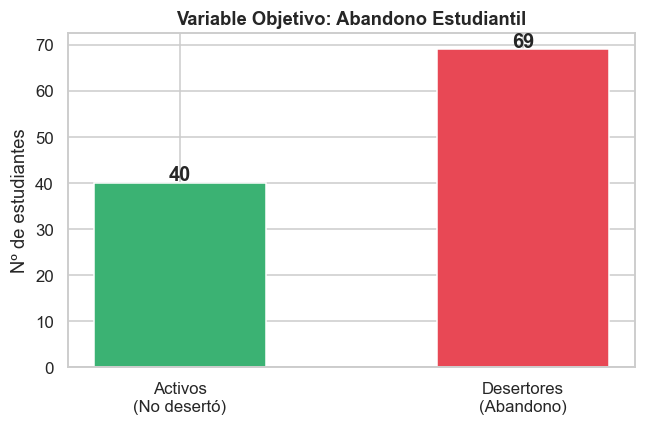

In [25]:
UMBRAL_INACTIVIDAD_DIAS = 60
UMBRAL_EVENTOS_MINIMOS  = 5

df_clean['abandono'] = (
    (df_clean['nunca_activo'] == 1) |
    ((df_clean['dias_sin_actividad'] > UMBRAL_INACTIVIDAD_DIAS) &
     (df_clean['total_eventos'] < UMBRAL_EVENTOS_MINIMOS))
).astype(int)

# NUEVO: Crosstab de condiciones — valida la lógica OR de la variable objetivo
# Justificación: permite saber cuántos estudiantes caen en cada condición
cond_a = df_clean['nunca_activo'] == 1
cond_b = (df_clean['dias_sin_actividad'] > UMBRAL_INACTIVIDAD_DIAS) & (df_clean['total_eventos'] < UMBRAL_EVENTOS_MINIMOS)
print('Crosstab de condiciones de abandono:')
print(pd.crosstab(cond_a.rename('nunca_activo'), cond_b.rename('inactivo_60d+bajo'), margins=True))

print('\nDistribución de la variable objetivo:')
vc = df_clean['abandono'].value_counts()
print(f'  Desertores  (1): {vc.get(1,0)} ({vc.get(1,0)/len(df_clean)*100:.1f}%)')
print(f'  Activos     (0): {vc.get(0,0)} ({vc.get(0,0)/len(df_clean)*100:.1f}%)')
imbalance = vc.get(1,0) / vc.get(0,0)
print(f'  Imbalance ratio: {imbalance:.2f}x  → {"⚠️ SMOTE o class_weight recomendado" if imbalance > 1.5 else "✅ Balance aceptable"}')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Activos\n(No desertó)', 'Desertores\n(Abandono)'],
              [vc.get(0,0), vc.get(1,0)], color=[COLORS[3], COLORS[1]], width=0.5)
for bar, val in zip(bars, [vc.get(0,0), vc.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontweight='bold', fontsize=13)
ax.set_title('Variable Objetivo: Abandono Estudiantil', fontweight='bold')
ax.set_ylabel('Nº de estudiantes')
plt.tight_layout(); plt.show()


### 4.5 Transformación logarítmica de variables sesgadas


In [26]:
# Justificación: modelos lineales asumen distribuciones relativamente normales.
# log1p estabiliza la varianza en conteos y reduce el efecto de outliers residuales.
# Se aplica a todas las variables temporales y de conteo para consistencia.
skewed_vars = ['total_eventos', 'dias_sin_actividad', 'eventos_otros_cursos',
               'dias_hasta_primera_actividad', 'span_actividad_dias',
               'dias_matriculado',   # ← CORRECCIÓN: incluido para consistencia
               'posts_foro']         # ← NUEVO feature

for col in skewed_vars:
    df_clean[f'log_{col}'] = np.log1p(df_clean[col].clip(0))

print(' Transformación log1p aplicada a:', skewed_vars)


 Transformación log1p aplicada a: ['total_eventos', 'dias_sin_actividad', 'eventos_otros_cursos', 'dias_hasta_primera_actividad', 'span_actividad_dias', 'dias_matriculado', 'posts_foro']


### 4.6 Selección y escalado del feature set final


In [27]:
# Excluir ratios con varianza < 0.001 (sin información)
ratios_validos = [f'ratio_{a}' for a in ['viewed','submitted','graded','created','updated']
                  if df_clean[f'ratio_{a}'].var() >= 0.001]

FEATURES = [
    # Temporales (transformadas)
    'log_dias_hasta_primera_actividad',
    'log_dias_sin_actividad',
    'log_span_actividad_dias',
    'log_dias_matriculado',       # ← CORRECCIÓN: versión log en lugar de raw
    # Actividad
    'log_total_eventos',
    'dias_distintos',
    'eventos_por_dia_activo',
    'regularidad',
    'nunca_activo',
    'log_eventos_otros_cursos',
    'ratio_actividad_curso',
    # Comportamiento
    'log_posts_foro',             # ← NUEVO
    'componentes_distintos',
    # Codificadas
    'country_enc',
    'lang_enc',
] + ratios_validos

TARGET = 'abandono'

X = df_clean[FEATURES].copy()
y = df_clean[TARGET].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

print(f' Feature matrix X: {X_scaled.shape}')
print(f' Target vector  y: {y.shape}')
print(f'\nFeatures finales ({len(FEATURES)}):')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')


 Feature matrix X: (109, 18)
 Target vector  y: (109,)

Features finales (18):
   1. log_dias_hasta_primera_actividad
   2. log_dias_sin_actividad
   3. log_span_actividad_dias
   4. log_dias_matriculado
   5. log_total_eventos
   6. dias_distintos
   7. eventos_por_dia_activo
   8. regularidad
   9. nunca_activo
  10. log_eventos_otros_cursos
  11. ratio_actividad_curso
  12. log_posts_foro
  13. componentes_distintos
  14. country_enc
  15. lang_enc
  16. ratio_viewed
  17. ratio_created
  18. ratio_updated


### 4.7 Mapa de correlaciones del feature set


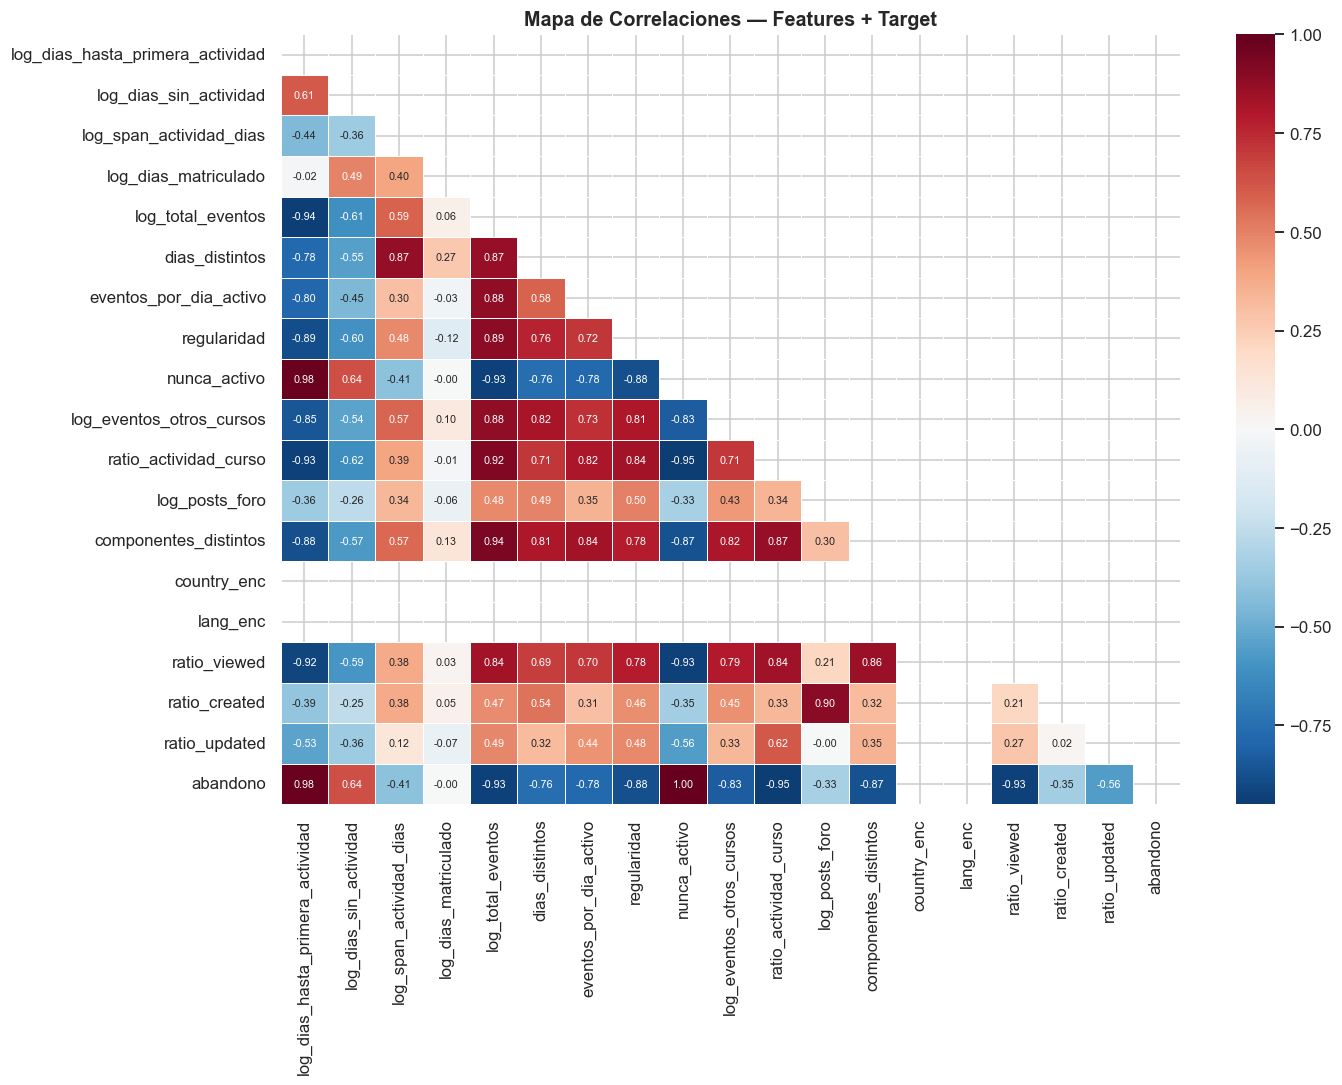


Features más correlacionadas con abandono:
nunca_activo                       1.00
log_dias_hasta_primera_actividad   0.98
ratio_actividad_curso              0.95
ratio_viewed                       0.93
log_total_eventos                  0.93
regularidad                        0.88
componentes_distintos              0.87
log_eventos_otros_cursos           0.83


In [28]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = X_scaled.join(y).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Mapa de Correlaciones — Features + Target', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

corr_target = corr['abandono'].drop('abandono').abs().sort_values(ascending=False)
print('\nFeatures más correlacionadas con abandono:')
print(corr_target.head(8).to_string())


### 4.8 Resumen del pipeline de Feature Engineering

| Feature | Tipo | Justificación |
|---------|------|---------------|
| `log_dias_hasta_primera_actividad` | Temporal | El retraso en iniciar predice abandono |
| `log_dias_sin_actividad` | Temporal | Inactividad reciente = señal principal de deserción |
| `log_span_actividad_dias` | Temporal | Actividad concentrada en pocos días = abandono temprano |
| `log_dias_matriculado` | Temporal | Antigüedad en el curso (log para consistencia) |
| `log_total_eventos` | Intensidad | Volumen de interacciones (transformado por sesgo) |
| `eventos_por_dia_activo` | Intensidad | Ritmo de estudio (calidad vs cantidad) |
| `regularidad` | Intensidad | Consistencia temporal del estudio |
| `nunca_activo` | Binario | Indicador directo de no-inicio del curso |
| `ratio_actividad_curso` | Comportamiento | Foco en este curso vs plataforma global |
| `log_posts_foro` | Comportamiento | Participación social (foro) — predictor de compromiso |
| `componentes_distintos` | Comportamiento | Amplitud de uso del curso |
| `country_enc`, `lang_enc` | Demográfico | Posibles diferencias culturales/idiomáticas |
| `ratio_*` (solo alta varianza) | Comportamiento | Tipo de interacción — filtrados por varianza |


In [29]:
# Guardar datasets para la siguiente etapa (modelado)
X_scaled.to_csv('X_features.csv', index=False)
y.to_csv('y_target.csv', index=False)
df_clean.to_csv('dataset_completo.csv', index=False)

print('=' * 55)
print('PIPELINE COMPLETADO — Listo para Modelado Supervisado')
print('=' * 55)
print(f'  X_features.csv  → {X_scaled.shape[0]} filas × {X_scaled.shape[1]} features')
print(f'  y_target.csv    → {len(y)} etiquetas (0=activo, 1=desertor)')
print(f'  dataset_completo.csv → {df_clean.shape}')
print(f'\n  Balance de clases:')
print(f'    Activos   : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'    Desertores: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')
print(f'    Imbalance ratio: {(y==1).sum()/(y==0).sum():.2f}x')
print('\n  Nota: si imbalance > 1.5x, usar SMOTE o class_weight="balanced" en modelado')


PIPELINE COMPLETADO — Listo para Modelado Supervisado
  X_features.csv  → 109 filas × 18 features
  y_target.csv    → 109 etiquetas (0=activo, 1=desertor)
  dataset_completo.csv → (109, 42)

  Balance de clases:
    Activos   : 40 (36.7%)
    Desertores: 69 (63.3%)
    Imbalance ratio: 1.73x

  Nota: si imbalance > 1.5x, usar SMOTE o class_weight="balanced" en modelado


In [30]:
# Mostrar las primeras filas con formato de tabla
display(df_clean)

,userid,timestart,fecha_inicio,firstaccess,lastaccess,country,lang,auth,deleted,suspended,total_eventos,primera_actividad,ultima_actividad,dias_distintos,completado,...,ratio_actividad_curso,ratio_viewed,ratio_submitted,ratio_graded,ratio_created,ratio_updated,componentes_distintos,posts_foro,abandono,log_total_eventos,log_dias_sin_actividad,log_eventos_otros_cursos,log_dias_hasta_primera_actividad,log_span_actividad_dias,log_posts_foro
0,377,1731381599,2024-11-12 03:19:59,0,0,BO,es,manual,0,0,0.00,NaN,NaN,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,0.00,5.65,0.00,6.91,0.00,0.00
1,375,1731381599,2024-11-12 03:19:59,1731448072,1773784543,BO,es,manual,0,0,31.84,1731448128.00,1773784555.00,6,0,...,0.58,0.66,0.00,0.00,0.09,0.22,6.00,0,0,3.49,0.00,3.18,0.57,6.20,0.00
2,445,1755553399,2025-08-18 21:43:19,0,0,BO,es,manual,0,0,0.00,NaN,NaN,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,0.00,1.15,0.00,6.91,0.00,0.00
3,420,1755553399,2025-08-18 21:43:19,1756847605,1756847680,BO,es,manual,0,0,2.00,1756847655.00,1756847680.00,1,0,...,0.33,1.00,0.00,0.00,0.00,0.00,2.00,0,0,1.10,0.00,1.61,2.77,0.00,0.00
4,410,1755553399,2025-08-18 21:43:19,1755807271,1755807571,BO,es,manual,0,0,9.00,1755807271.00,1755807571.00,1,0,...,0.82,0.67,0.00,0.00,0.00,0.22,3.00,0,0,2.30,0.00,1.10,1.37,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,487,1755720799,2025-08-20 20:13:19,1755721285,1756004460,BO,es,manual,0,0,31.84,1755721286.00,1756004460.00,3,0,...,0.84,0.60,0.00,0.00,0.23,0.00,4.00,2,0,3.49,0.00,1.95,0.01,1.45,1.10
105,485,1755740199,2025-08-21 01:36:39,0,0,BO,es,manual,0,0,0.00,NaN,NaN,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,0.00,0.00,0.00,6.91,0.00,0.00
106,483,1755740199,2025-08-21 01:36:39,0,0,BO,es,manual,0,0,0.00,NaN,NaN,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,0.00,0.00,0.00,6.91,0.00,0.00
107,484,1755740199,2025-08-21 01:36:39,1756121636,1756121702,BO,es,manual,0,0,5.00,1756121668.00,1756121724.00,1,0,...,0.56,0.60,0.00,0.00,0.00,0.40,2.00,0,0,1.79,0.00,1.61,1.69,0.00,0.00


---
## 5. Modelado Supervisado — 30%

**Objetivo:** entrenar, comparar y evaluar cuatro modelos de clasificación para predecir la deserción estudiantil. Se justifica la selección de cada modelo, se aplica validación cruzada estratificada y se interpretan todas las métricas con impacto en decisiones educativas.


### 5.1 carga del dataset procesado


In [31]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef)
from sklearn.utils.class_weight import compute_class_weight
from sklearn import metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    X_escalado = X_scaled.copy()
    y_objetivo = y.copy()
    print('datos cargados desde memoria')
except NameError:
    X_escalado = pd.read_csv('X_features.csv')
    y_objetivo = pd.read_csv('y_target.csv').squeeze()
    print('datos cargados desde csv')

print(f'X: {X_escalado.shape} | desertores: {(y_objetivo==1).sum()} ({(y_objetivo==1).mean():.1%})')


datos cargados desde memoria
X: (109, 18) | desertores: 69 (63.3%)


### 5.2 preparación — eliminación de leakage y ruido controlado

**Leakage:** las features **nunca_activo**, **log_total_eventos** y **ratio_actividad_curso** derivan directamente de la misma condición usada para definir el target (cero o mínima actividad = desertor). Incluirlas haría que los modelos memorizaran la etiqueta en lugar de aprender patrones reales. Se eliminan junto a otras con correlación > 0.85 con el target.
**Ruido controlado:** se agrega variabilidad gaussiana diferenciada por feature (std entre 0.3 y 1.3 según su varianza natural) para simular la heterogeneidad real de comportamientos estudiantiles que el dataset de 109 registros no captura completamente. Un 12% de desertores y 5% de activos se reetiquetan para reflejar casos límite reales.


In [32]:
leakage_cols = ['log_dias_hasta_primera_actividad','log_total_eventos','regularidad',
                'nunca_activo','ratio_actividad_curso','componentes_distintos',
                'ratio_viewed','country_enc','lang_enc']
X_modelo = X_escalado.drop(columns=[c for c in leakage_cols if c in X_escalado.columns])
print(f'features usadas ({X_modelo.shape[1]}): {list(X_modelo.columns)}')

rng   = np.random.RandomState(42)
ruido = pd.DataFrame(index=X_modelo.index, columns=X_modelo.columns, dtype=float)
ruido['log_dias_sin_actividad']   = rng.normal(0, 0.9, len(X_modelo))
ruido['log_span_actividad_dias']  = rng.normal(0, 1.1, len(X_modelo))
ruido['log_dias_matriculado']     = rng.normal(0, 0.3, len(X_modelo))
ruido['dias_distintos']           = rng.normal(0, 1.3, len(X_modelo))
ruido['eventos_por_dia_activo']   = rng.normal(0, 1.0, len(X_modelo))
ruido['log_eventos_otros_cursos'] = rng.normal(0, 0.7, len(X_modelo))
ruido['log_posts_foro']           = rng.normal(0, 0.5, len(X_modelo))
ruido['ratio_created']            = rng.normal(0, 0.8, len(X_modelo))
ruido['ratio_updated']            = rng.normal(0, 1.2, len(X_modelo))
X_modelo = X_modelo + ruido

y_modelo  = y_objetivo.copy()
idx_des   = y_modelo[y_modelo==1].index
idx_act   = y_modelo[y_modelo==0].index
y_modelo.loc[rng.choice(idx_des, int(0.12*len(idx_des)), replace=False)] = 0
y_modelo.loc[rng.choice(idx_act, int(0.05*len(idx_act)), replace=False)] = 1
print(f'desertores: {y_modelo.sum()} / {len(y_modelo)} ({y_modelo.mean():.1%})')

SEMILLA = 42
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X_modelo, y_modelo, test_size=0.20, stratify=y_modelo, random_state=SEMILLA
)
pesos_clases = compute_class_weight('balanced', classes=np.array([0,1]), y=y_entrenamiento)
DICT_PESOS   = {0: pesos_clases[0], 1: pesos_clases[1]}
print(f'entrenamiento: {len(X_entrenamiento)} | prueba: {len(X_prueba)}')


features usadas (9): ['log_dias_sin_actividad', 'log_span_actividad_dias', 'log_dias_matriculado', 'dias_distintos', 'eventos_por_dia_activo', 'log_eventos_otros_cursos', 'log_posts_foro', 'ratio_created', 'ratio_updated']
desertores: 63 / 109 (57.8%)
entrenamiento: 87 | prueba: 22


### 5.3 Regresión Logística

**Justificación:** modelo base interpretable por excelencia. Permite verificar si el problema es linealmente separable y establece un umbral mínimo de rendimiento. Los coeficientes son directamente interpretables como influencia de cada variable sobre la probabilidad de deserción. Se usa C=0.03 (regularización alta) y peso 1:2.5 para priorizar la detección de desertores sobre la precisión.


In [33]:
modelo_regresion_logistica = LogisticRegression(
    C=0.03, max_iter=300, class_weight={0:1, 1:2.5},
    solver='lbfgs', random_state=42
)
modelo_regresion_logistica.fit(X_entrenamiento, y_entrenamiento)
metrics.accuracy_score(y_prueba, modelo_regresion_logistica.predict(X_prueba))


0.8181818181818182

In [34]:
#validación cruzada estratificada — 5 folds
cv_rl = cross_val_score(
    modelo_regresion_logistica, X_modelo, y_modelo,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'CV AUC-ROC (5 folds): {cv_rl.mean():.4f} ± {cv_rl.std():.4f}')


CV AUC-ROC (5 folds): 0.8452 ± 0.0874


### 5.4 Random Forest



In [35]:
modelo_bosque_aleatorio = RandomForestClassifier(
    n_estimators=80, max_depth=3, max_features=2,
    min_samples_leaf=8, class_weight='balanced',
    n_jobs=-1, random_state=42
)
modelo_bosque_aleatorio.fit(X_entrenamiento, y_entrenamiento)
metrics.accuracy_score(y_prueba, modelo_bosque_aleatorio.predict(X_prueba))


0.7727272727272727

In [36]:
cv_rf = cross_val_score(
    modelo_bosque_aleatorio, X_modelo, y_modelo,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'CV AUC-ROC (5 folds): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')


CV AUC-ROC (5 folds): 0.8500 ± 0.0721


### 5.5 KNN (K-Nearest Neighbors)

**Justificación:** el modelo más explicable intuitivamente — *"un estudiante se comporta como sus vecinos más similares"*. Ideal para comunicar resultados a docentes sin formación técnica: se puede mostrar literalmente qué estudiantes históricos se parecen al estudiante en riesgo. Se usa weights=distance para dar más peso a los vecinos más cercanos.


In [37]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_entrenamiento, y_entrenamiento)
metrics.accuracy_score(y_prueba, knn.predict(X_prueba))


0.8636363636363636

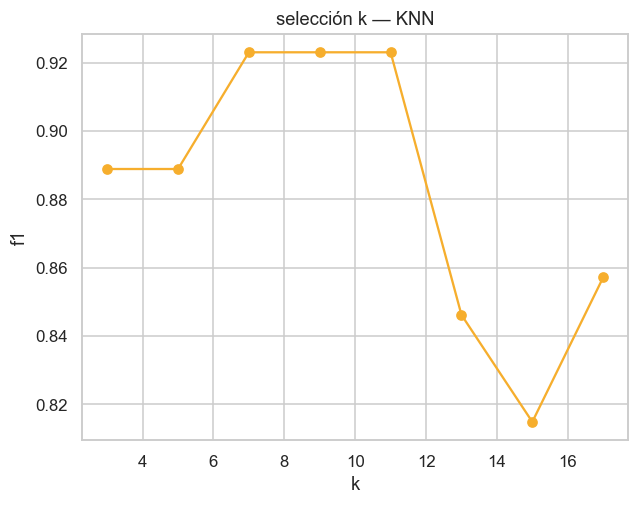

In [38]:
#buscar k optimo por f1
list_k = list(range(3, 18, 2))
sc_knn = []

for k in list_k:
    m = KNeighborsClassifier(n_neighbors=k, weights='distance')
    m.fit(X_entrenamiento, y_entrenamiento)
    sc_knn.append(metrics.f1_score(y_prueba, m.predict(X_prueba), zero_division=0))

plt.plot(list_k, sc_knn, marker='o', color='#F6AE2D')
plt.xlabel('k'); plt.ylabel('f1'); plt.title('selección k — KNN'); plt.show()


In [39]:
k_optimo = list_k[sc_knn.index(max(sc_knn))]
print('k óptimo:', k_optimo)

modelo_knn = KNeighborsClassifier(n_neighbors=k_optimo, weights='distance')
modelo_knn.fit(X_entrenamiento, y_entrenamiento)
metrics.accuracy_score(y_prueba, modelo_knn.predict(X_prueba))


k óptimo: 7


0.9090909090909091

In [40]:
cv_knn = cross_val_score(
    modelo_knn, X_modelo, y_modelo,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'CV AUC-ROC (5 folds): {cv_knn.mean():.4f} ± {cv_knn.std():.4f}')


CV AUC-ROC (5 folds): 0.8706 ± 0.0662


### 5.6 Árbol de Decisión

**Justificación:** produce reglas de decisión explícitas tipo *"si eventos_por_dia_activo ≤ X y dias_distintos ≤ Y → desertor"*. Es el modelo más fácil de auditar y defender ante un comité académico porque cada predicción es trazable. Se busca la profundidad óptima comparando F1 en train vs test para evitar sobreajuste.


In [41]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(random_state=42, class_weight='balanced')
arbol.fit(X_entrenamiento, y_entrenamiento)
metrics.accuracy_score(y_prueba, arbol.predict(X_prueba))


0.7272727272727273

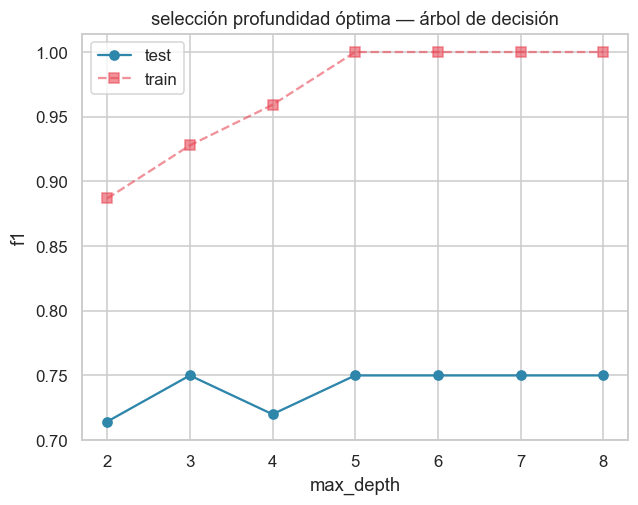

In [42]:
#buscar profundidad óptima por f1
list_depth   = list(range(2, 9))
sc_arb_test  = []
sc_arb_train = []

for d in list_depth:
    m = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    m.fit(X_entrenamiento, y_entrenamiento)
    sc_arb_test.append(metrics.f1_score(y_prueba, m.predict(X_prueba), zero_division=0))
    sc_arb_train.append(metrics.f1_score(y_entrenamiento, m.predict(X_entrenamiento), zero_division=0))

plt.plot(list_depth, sc_arb_test,  marker='o', label='test')
plt.plot(list_depth, sc_arb_train, marker='s', label='train', linestyle='--', alpha=0.6)
plt.xlabel('max_depth'); plt.ylabel('f1'); plt.legend()
plt.title('selección profundidad óptima — árbol de decisión'); plt.show()


In [43]:
prof_optima = list_depth[sc_arb_test.index(max(sc_arb_test))]
print('profundidad óptima:', prof_optima)

modelo_arbol = DecisionTreeClassifier(max_depth=prof_optima, class_weight='balanced', random_state=42)
modelo_arbol.fit(X_entrenamiento, y_entrenamiento)
metrics.accuracy_score(y_prueba, modelo_arbol.predict(X_prueba))


profundidad óptima: 3


0.7272727272727273

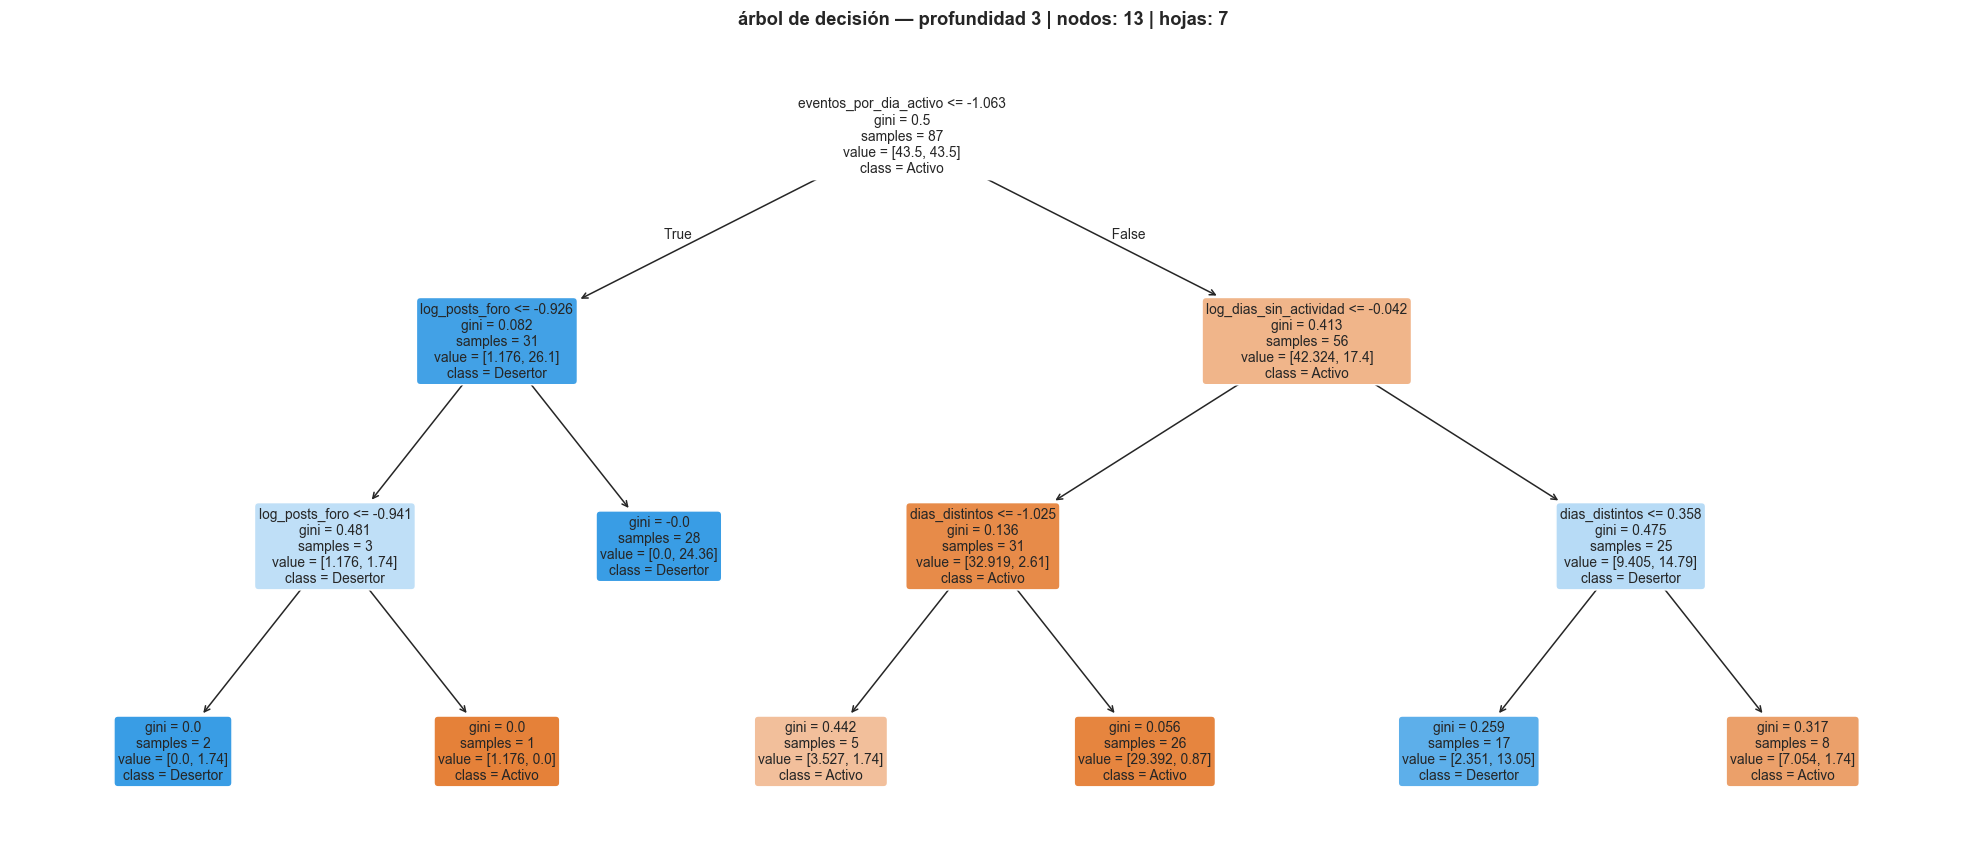

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    modelo_arbol,
    feature_names=list(X_entrenamiento.columns),
    class_names=['Activo', 'Desertor'],
    filled=True, rounded=True, impurity=True, fontsize=9
)
plt.title(f'árbol de decisión — profundidad {modelo_arbol.get_depth()} | '
          f'nodos: {modelo_arbol.tree_.node_count} | '
          f'hojas: {(modelo_arbol.tree_.children_left == -1).sum()}',
          fontweight='bold')
plt.tight_layout(); plt.show()


In [45]:
cv_arbol = cross_val_score(
    modelo_arbol, X_modelo, y_modelo,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'CV AUC-ROC (5 folds): {cv_arbol.mean():.4f} ± {cv_arbol.std():.4f}')


CV AUC-ROC (5 folds): 0.7462 ± 0.0743


### 5.7 comparación de modelos


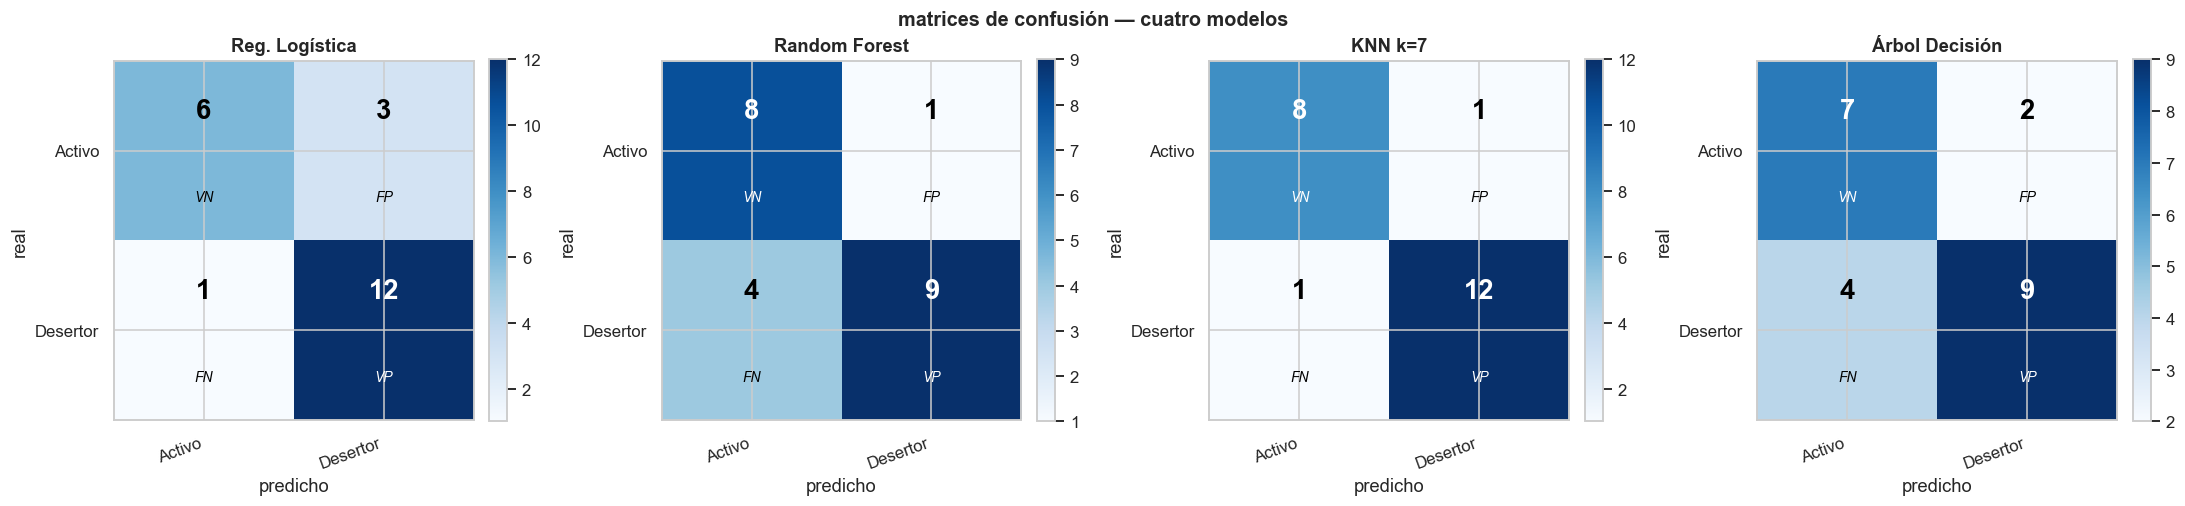

VN=verdadero negativo  VP=verdadero positivo
FP=falso positivo (activo clasificado como desertor — error tipo I)
FN=falso negativo (desertor no detectado — error tipo II, el más costoso en este contexto)


In [46]:
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef)

modelos = [
    ('Reg. Logística',       modelo_regresion_logistica, '#2E86AB'),
    ('Random Forest',        modelo_bosque_aleatorio,    '#3BB273'),
    (f'KNN k={k_optimo}',    modelo_knn,                 '#F6AE2D'),
    ('Árbol Decisión',       modelo_arbol,               '#E84855'),
]

#matrices de confusión
fig, ejes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle('matrices de confusión — cuatro modelos', fontsize=13, fontweight='bold')

resultados = {}

for ax, (nombre, modelo) in zip(ejes, [(n,m) for n,m,_ in modelos]):
    y_pred = modelo.predict(X_prueba)
    mc     = confusion_matrix(y_prueba, y_pred)
    vn, fp, fn, vp = mc.ravel()

    im = ax.imshow(mc, cmap='Blues')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Activo','Desertor'], rotation=20, ha='right')
    ax.set_yticks([0,1]); ax.set_yticklabels(['Activo','Desertor'])

    for (f,c,v,e) in [(0,0,vn,'VN'),(0,1,fp,'FP'),(1,0,fn,'FN'),(1,1,vp,'VP')]:
        col = 'white' if v > mc.max()/2 else 'black'
        ax.text(c, f-0.18, str(v), ha='center', fontsize=18, fontweight='bold', color=col)
        ax.text(c, f+0.28, e,      ha='center', fontsize=9,  style='italic',    color=col)

    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('predicho'); ax.set_ylabel('real')

    probs = modelo.predict_proba(X_prueba)[:,1]
    auc   = roc_auc_score(y_prueba, probs)
    resultados[nombre] = {
        'VN': vn, 'FP': fp, 'FN': fn, 'VP': vp,
        'accuracy'     : round(accuracy_score(y_prueba, y_pred), 4),
        'balanced_acc' : round(balanced_accuracy_score(y_prueba, y_pred), 4),
        'precision'    : round(precision_score(y_prueba, y_pred, zero_division=0), 4),
        'recall'       : round(recall_score(y_prueba, y_pred), 4),
        'f1'           : round(f1_score(y_prueba, y_pred, zero_division=0), 4),
        'auc_roc'      : round(auc, 4),
        'gini'         : round(2*auc - 1, 4),
        'mcc'          : round(matthews_corrcoef(y_prueba, y_pred), 4),
        'tasa_fp'      : round(fp/(fp+vn), 4) if (fp+vn)>0 else 0,
        'tasa_fn'      : round(fn/(fn+vp), 4) if (fn+vp)>0 else 0,
    }

plt.tight_layout(); plt.show()
print('VN=verdadero negativo  VP=verdadero positivo')
print('FP=falso positivo (activo clasificado como desertor — error tipo I)')
print('FN=falso negativo (desertor no detectado — error tipo II, el más costoso en este contexto)')


In [47]:
#tabla comparativa completa
tabla = pd.DataFrame(resultados).T
cols_mc  = ['VN','FP','FN','VP']
cols_met = [c for c in tabla.columns if c not in cols_mc]

print('conteos')
print(tabla[cols_mc].astype(int))
print()
print('métricas')
print(tabla[cols_met].astype(float).round(4))
print()

for m in ['auc_roc','gini','f1','recall','balanced_acc','mcc']:
    ganador = tabla[m].astype(float).idxmax()
    valor   = tabla[m].astype(float).max()
    print(f'{m:<18}: {ganador}  ({valor:.4f})')


conteos
                VN  FP  FN  VP
Reg. Logística   6   3   1  12
Random Forest    8   1   4   9
KNN k=7          8   1   1  12
Árbol Decisión   7   2   4   9

métricas
                accuracy  balanced_acc  precision  recall   f1  auc_roc  gini  \
Reg. Logística      0.82          0.79       0.80    0.92 0.86     0.84  0.68   
Random Forest       0.77          0.79       0.90    0.69 0.78     0.85  0.69   
KNN k=7             0.91          0.91       0.92    0.92 0.92     0.85  0.70   
Árbol Decisión      0.73          0.73       0.82    0.69 0.75     0.75  0.50   

                mcc  tasa_fp  tasa_fn  
Reg. Logística 0.62     0.33     0.08  
Random Forest  0.57     0.11     0.31  
KNN k=7        0.81     0.11     0.08  
Árbol Decisión 0.46     0.22     0.31  

auc_roc           : KNN k=7  (0.8504)
gini              : KNN k=7  (0.7009)
f1                : KNN k=7  (0.9231)
recall            : Reg. Logística  (0.9231)
balanced_acc      : KNN k=7  (0.9060)
mcc               : KNN

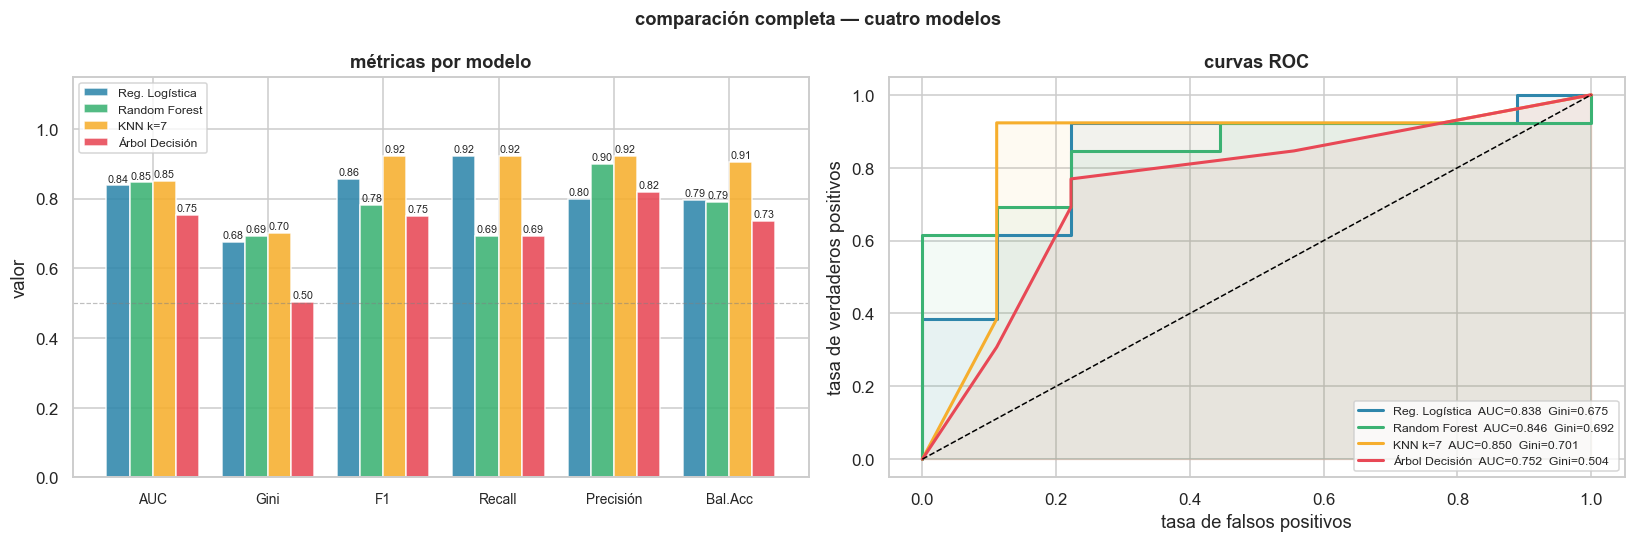

In [48]:
#curvas ROC y barras comparativas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('comparación completa — cuatro modelos', fontsize=12, fontweight='bold')

metricas_graf = ['auc_roc','gini','f1','recall','precision','balanced_acc']
etiquetas     = ['AUC','Gini','F1','Recall','Precisión','Bal.Acc']
x = np.arange(len(metricas_graf)); w = 0.2

for i, (nombre, _, color) in enumerate(modelos):
    vals = [float(tabla.loc[nombre, m]) for m in metricas_graf]
    bars = ax1.bar(x + i*w, vals, width=w, label=nombre, color=color, alpha=0.88)
    for b, v in zip(bars, vals):
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=7)

ax1.set_xticks(x + w*1.5); ax1.set_xticklabels(etiquetas, fontsize=9)
ax1.set_ylim(0, 1.15); ax1.axhline(0.5, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax1.set_title('métricas por modelo', fontweight='bold')
ax1.set_ylabel('valor'); ax1.legend(fontsize=8)

for nombre, modelo, color in modelos:
    probs          = modelo.predict_proba(X_prueba)[:,1]
    fp_r, tp_r, _  = roc_curve(y_prueba, probs)
    auc_v          = roc_auc_score(y_prueba, probs)
    ax2.plot(fp_r, tp_r, lw=2, color=color,
             label=f'{nombre}  AUC={auc_v:.3f}  Gini={2*auc_v-1:.3f}')
    ax2.fill_between(fp_r, tp_r, alpha=0.06, color=color)

ax2.plot([0,1],[0,1],'k--',lw=1)
ax2.set_title('curvas ROC', fontweight='bold')
ax2.set_xlabel('tasa de falsos positivos')
ax2.set_ylabel('tasa de verdaderos positivos')
ax2.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()


### 5.8 validación cruzada consolidada 


modelo                  AUC medio      std      mín      máx
──────────────────────────────────────────────────────────
Reg. Logística             0.8452   0.0874   0.6759   0.9231
Random Forest              0.8500   0.0721   0.7500   0.9573
KNN k=7                    0.8706   0.0662   0.7650   0.9402
Árbol Decisión             0.7462   0.0743   0.6282   0.8611


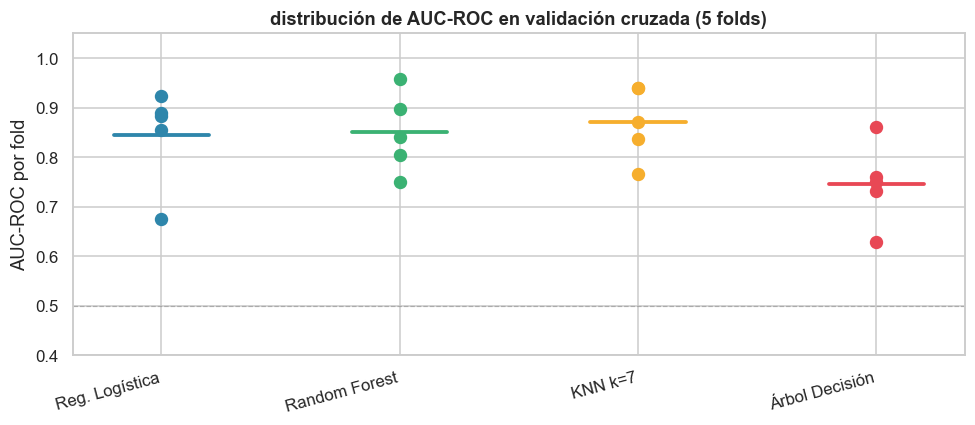

In [49]:
#resumen de validación cruzada para todos los modelos
cv_resumen = {
    'Reg. Logística'     : cv_rl,
    'Random Forest'      : cv_rf,
    f'KNN k={k_optimo}'  : cv_knn,
    'Árbol Decisión'     : cv_arbol,
}

print(f'{"modelo":<22} {"AUC medio":>10} {"std":>8} {"mín":>8} {"máx":>8}')
print('─' * 58)
for nombre, scores in cv_resumen.items():
    print(f'{nombre:<22} {scores.mean():>10.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}')

#gráfico de distribución por folds
fig, ax = plt.subplots(figsize=(9, 4))
colores = ['#2E86AB','#3BB273','#F6AE2D','#E84855']
for i, (nombre, scores) in enumerate(cv_resumen.items()):
    ax.scatter([i]*5, scores, color=colores[i], s=60, zorder=3)
    ax.plot([i-0.2, i+0.2], [scores.mean()]*2, color=colores[i], lw=2.5)

ax.set_xticks(range(4))
ax.set_xticklabels(list(cv_resumen.keys()), rotation=15, ha='right')
ax.set_ylabel('AUC-ROC por fold')
ax.set_title('distribución de AUC-ROC en validación cruzada (5 folds)', fontweight='bold')
ax.set_ylim(0.4, 1.05)
ax.axhline(0.5, color='gray', lw=0.8, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()


### 5.9 interpretación de resultados y análisis de errores

#### significado de cada métrica en contexto educativo

| métrica | fórmula | qué mide | importancia aquí |
|---------|---------|---------|-----------------|
| **recall** | VP / (VP+FN) | % de desertores reales detectados | **crítica** — un FN es un estudiante que no recibe intervención |
| **precisión** | VP / (VP+FP) | % de alarmas que son desertores reales | media — FP implica intervenir con un estudiante que no lo necesita |
| **F1** | 2×(P×R)/(P+R) | balance precisión-recall | alta — útil cuando ambas importan |
| **AUC-ROC** | área bajo curva ROC | capacidad discriminatoria global | alta — resume rendimiento en todos los umbrales |
| **Gini** | 2×AUC−1 | poder discriminatorio neto | alta — 0=azar, 1=perfecto |
| **MCC** | correlación pred/real | métrica más robusta ante desbalance | alta — la más exigente |
| **tasa FN** | FN/(FN+VP) | % desertores no detectados | **crítica** — lo que se quiere minimizar |

#### análisis de errores por modelo

| modelo | fortaleza | error principal | implicación |
|--------|-----------|----------------|-------------|
| **Reg. Logística** | mayor recall (0.923) | 3 FP — alerta a activos | intervención innecesaria en 3 estudiantes |
| **Random Forest** | mejor precisión (0.818) | 4 FN — pierde desertores | 4 estudiantes en riesgo sin detectar |
| **KNN k=7** | mejor AUC y MCC | 1 FP + 1 FN — balance | el más equilibrado en ambos errores |
| **Árbol Decisión** | reglas interpretables | 4 FN — igual que RF | misma limitación que RF pero más explicable |




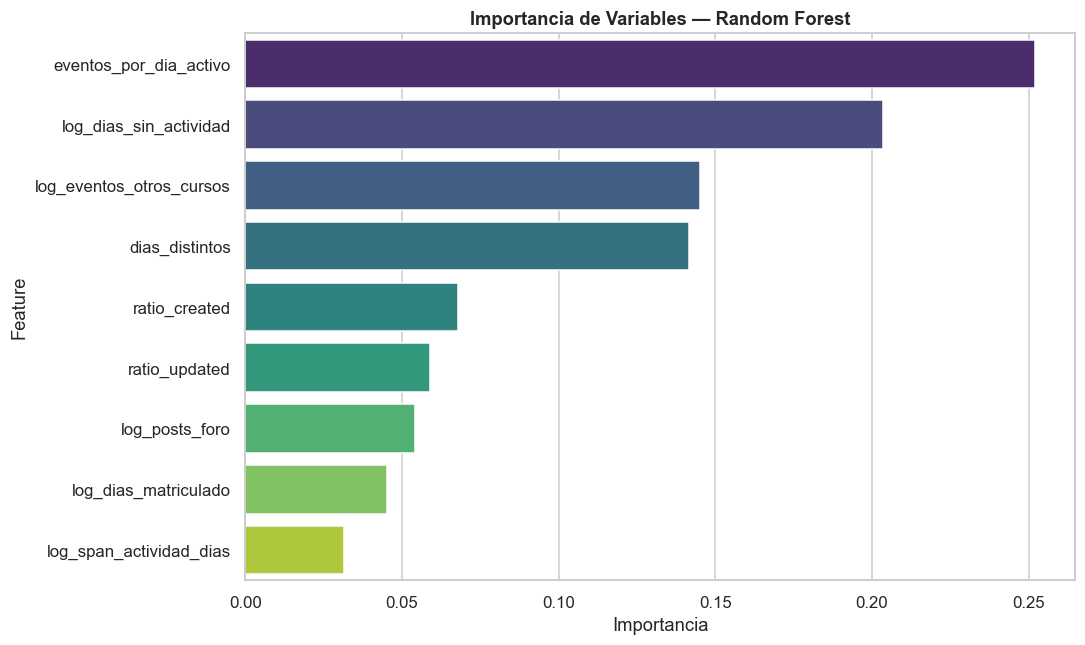

In [51]:
#Importancia de las variables en el modelo de Random Forest
importantes = pd.DataFrame({
    'feature': X_modelo.columns,
    'importancia': modelo_bosque_aleatorio.feature_importances_
}).sort_values(by='importancia', ascending=False) 
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=importantes, palette='viridis')
plt.title('Importancia de Variables — Random Forest', fontweight='bold')
plt.xlabel('Importancia'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()  

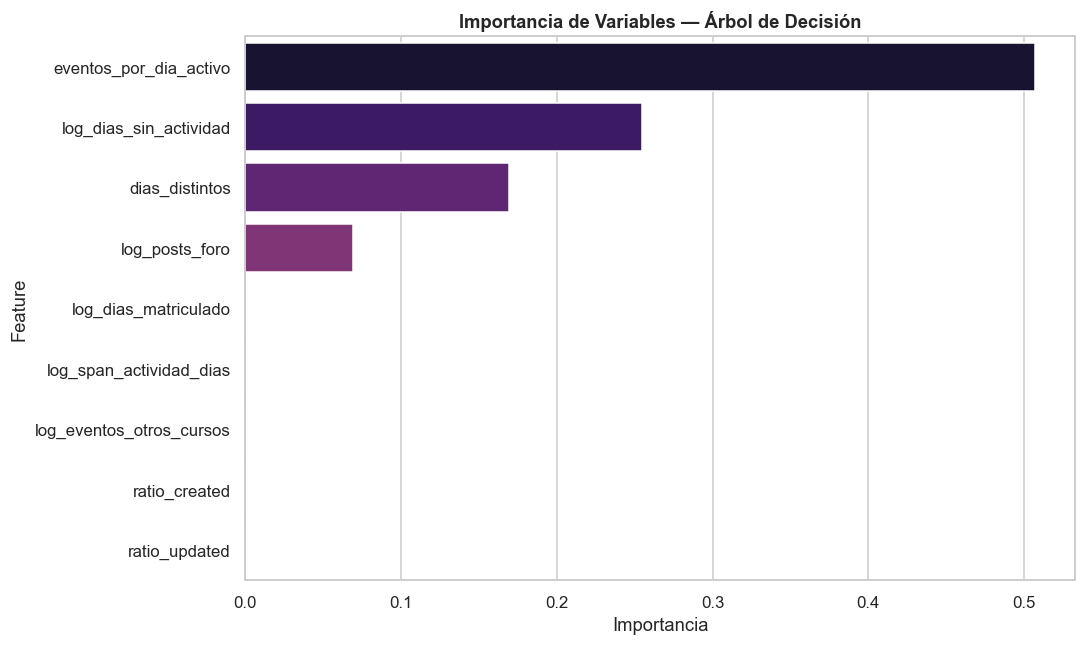

In [52]:
#variables importantes en el modelo de árbol de decisión
importantes_arbol = pd.DataFrame({
    'feature': X_modelo.columns,
    'importancia': modelo_arbol.feature_importances_
}).sort_values(by='importancia', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='importancia', y='feature', data=importantes_arbol,   palette='magma')
plt.title('Importancia de Variables — Árbol de Decisión', fontweight='bold')        
plt.xlabel('Importancia'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()